In [1]:
# Jupyter cell: make & save a vertical water-depth colorbar PNG
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import display, Image as IPyImage


def save_water_depth_colorbar_png(
    out_path="water_depth_cbar_vertical.png",
    *,
    edges=(0.05, 0.10, 0.30, 0.50, 1.00, 1.50, 2.00, 2.50, 3.00, 3.50),
    colors=(
        "#f7fcf0",  # 0.05–0.10
        "#ccebc5",  # 0.10–0.30
        "#a8ddb5",  # 0.30–0.50
        "#7bccc4",  # 0.50–1.00
        "#4eb3d3",  # 1.00–1.50
        "#2b8cbe",  # 1.50–2.00
        "#08589e",  # 2.00–2.50
        "#08306b",  # 2.50–3.00
        "#54278f",  # 3.00–3.50
    ),
    overflow_color="#4d004b",   # ≥ 3.5 m
    label="Water depth (m)",
    fig_height=5.5,
    fig_width=1.6,
    dpi=400
):
    """
    Creates a vertical discrete colorbar matching the LISFLOOD
    water-depth plots (including violet overflow) and saves it as PNG.
    """
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)

    # --- build cmap & norm ---
    colors_ext = list(colors) + [overflow_color]
    cmap_disc = ListedColormap(colors_ext)
    cmap_disc.set_under((0, 0, 0, 0))  # transparent for < first edge
    norm = BoundaryNorm(edges, cmap_disc.N, extend="max")

    # --- figure ---
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    ax = fig.add_axes([0.35, 0.05, 0.25, 0.90])  # [left, bottom, width, height]

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_disc)
    sm.set_array([])

    cbar = plt.colorbar(
        sm,
        cax=ax,
        orientation="vertical",
        extend="max",
        ticks=list(edges),
    )

    cbar.set_label(label, rotation=90, labelpad=12, fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    # clean look
    for spine in ("top", "right", "left", "bottom"):
        cbar.ax.spines[spine].set_visible(False)

    fig.patch.set_alpha(0.0)
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=True)
    plt.close(fig)

    print(f"✅ Saved colorbar to: {out_path}")
    display(IPyImage(filename=out_path))


✅ Saved colorbar to: /storage/homefs/ge24z347/Liestal_event/water_depth_cbar_vertical.png


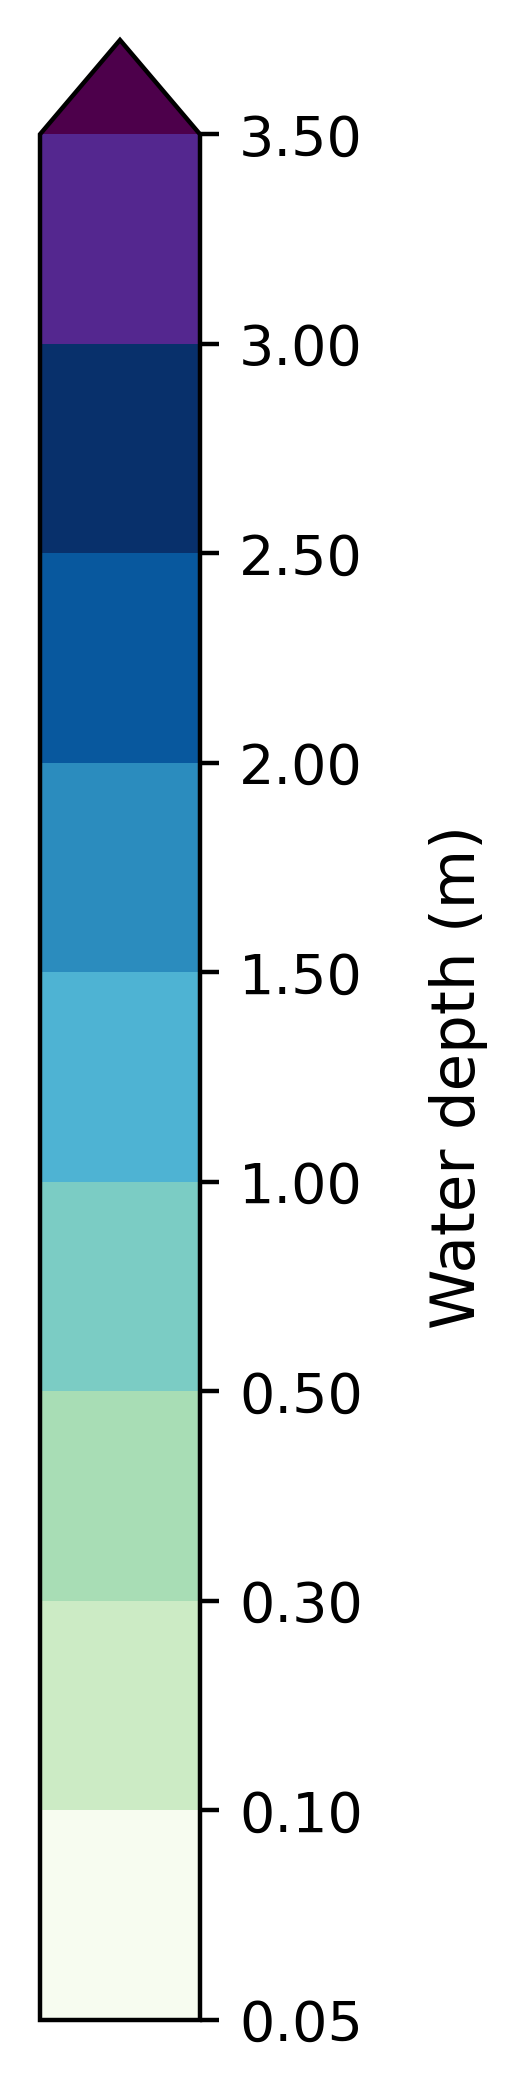

In [2]:
save_water_depth_colorbar_png(
    out_path="/storage/homefs/ge24z347/Liestal_event/water_depth_cbar_vertical.png",
    label="Water depth (m)"
)

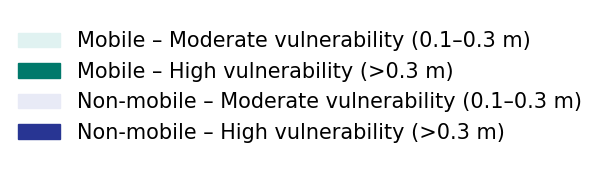

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create empty figure
fig, ax = plt.subplots(figsize=(2, 2))

# Remove axes
ax.axis("off")

legend_elements = [
    mpatches.Patch(color="#E0F2F1", label="Mobile – Moderate vulnerability (0.1–0.3 m)"),
    mpatches.Patch(color="#00796B", label="Mobile – High vulnerability (>0.3 m)"),
    mpatches.Patch(color="#E8EAF6", label="Non-mobile – Moderate vulnerability (0.1–0.3 m)"),
    mpatches.Patch(color="#283593", label="Non-mobile – High vulnerability (>0.3 m)"),
]

# Add legend in center
ax.legend(
    handles=legend_elements,
    loc="center",
    frameon=False, fontsize=15
)

plt.show()

In [ ]:
#####

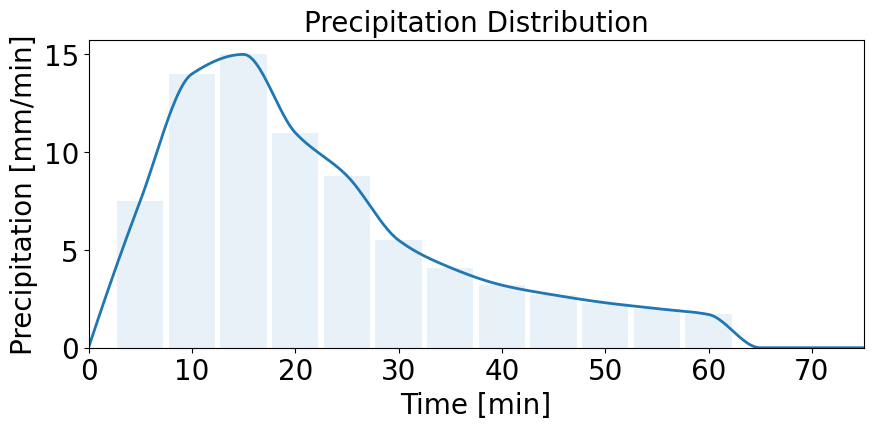

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

time = np.arange(0, 80, 5)
precip = np.array([0, 7.5, 14, 15, 11, 8.8, 5.5, 4.1, 3.2, 2.7, 2.3, 2.0, 1.7, 0, 0, 0])

x_smooth = np.linspace(time.min(), time.max(), 400)
pchip = PchipInterpolator(time, precip)
y_smooth = pchip(x_smooth)

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(time, precip, width=4.5, align="center", alpha=0.1)
ax.plot(x_smooth, y_smooth, linewidth=2)

# Labels with fontsize
label_fs = 20
ax.set_xlabel("Time [min]", fontsize=label_fs)
ax.set_ylabel("Precipitation [mm/min]", fontsize=label_fs)
ax.set_title("Precipitation Distribution", fontsize=label_fs)

# Tick labels same size as axis labels
ax.tick_params(axis="both", labelsize=label_fs)

ax.set_xlim(0, 75)

ax.grid(False)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.show()


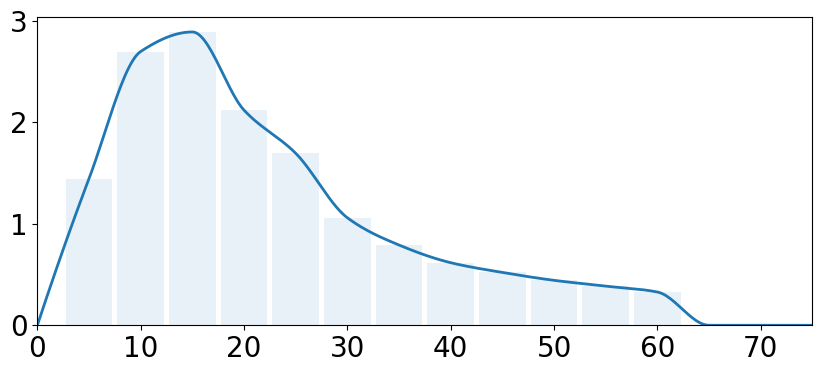

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

time = np.arange(0, 80, 5)
precip = np.array([0.0,1.446,2.699,2.892,2.121,1.696,1.060,0.791,0.617,0.521,0.443,0.386,0.328,0.0,0.0,0.0])

x_smooth = np.linspace(time.min(), time.max(), 400)
pchip = PchipInterpolator(time, precip)
y_smooth = pchip(x_smooth)

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(time, precip, width=4.5, align="center", alpha=0.1)
ax.plot(x_smooth, y_smooth, linewidth=2)

# Labels with fontsize
label_fs = 20
ax.set_xlabel("", fontsize=label_fs)
ax.set_ylabel("", fontsize=label_fs)
ax.set_title("", fontsize=label_fs)

# Tick labels same size as axis labels
ax.tick_params(axis="both", labelsize=label_fs)

ax.set_xlim(0, 75)

ax.grid(False)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.show()

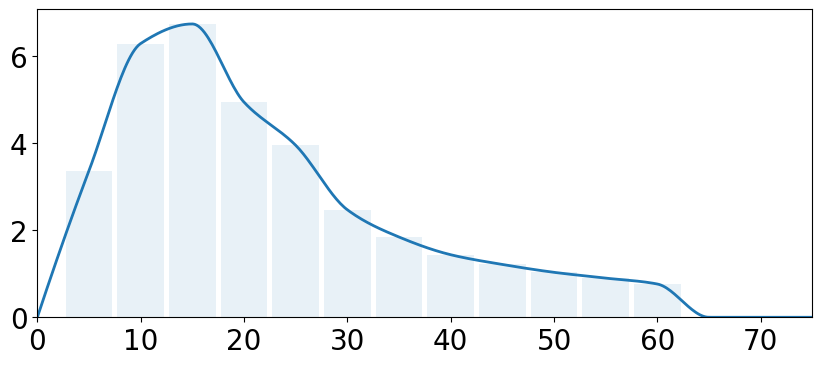

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

time = np.arange(0, 80, 5)
precip = np.array([0.0,3.374,6.298,6.748,4.949,3.957,2.473,1.846,1.439,1.215,1.034,0.901,0.765,0.0,0.0,0.0])

x_smooth = np.linspace(time.min(), time.max(), 400)
pchip = PchipInterpolator(time, precip)
y_smooth = pchip(x_smooth)

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(time, precip, width=4.5, align="center", alpha=0.1)
ax.plot(x_smooth, y_smooth, linewidth=2)

# Labels with fontsize
label_fs = 20
ax.set_xlabel("", fontsize=label_fs)
ax.set_ylabel("", fontsize=label_fs)
ax.set_title("", fontsize=label_fs)

# Tick labels same size as axis labels
ax.tick_params(axis="both", labelsize=label_fs)

ax.set_xlim(0, 75)

ax.grid(False)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.show()

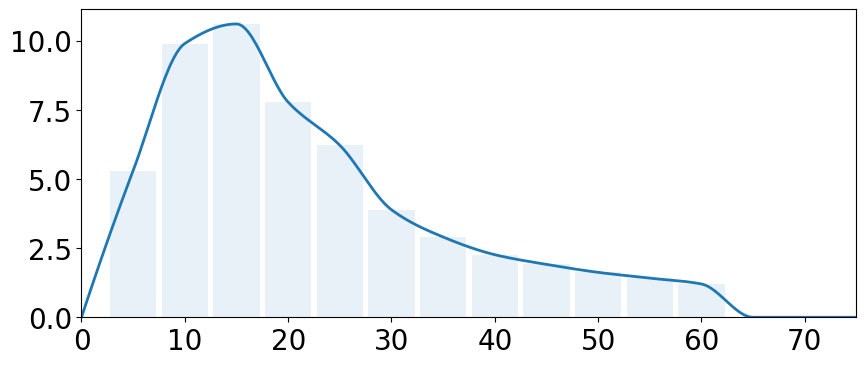

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

time = np.arange(0, 80, 5)
precip = np.array([0.0,5.302,9.897,10.604,7.777,6.219,3.887,2.901,2.262,1.911,1.624,1.415,1.203,0.0,0.0,0.0])

x_smooth = np.linspace(time.min(), time.max(), 400)
pchip = PchipInterpolator(time, precip)
y_smooth = pchip(x_smooth)

fig, ax = plt.subplots(figsize=(10,4))

ax.bar(time, precip, width=4.5, align="center", alpha=0.1)
ax.plot(x_smooth, y_smooth, linewidth=2)

# Labels with fontsize
label_fs = 20
ax.set_xlabel("", fontsize=label_fs)
ax.set_ylabel("", fontsize=label_fs)
ax.set_title("", fontsize=label_fs)

# Tick labels same size as axis labels
ax.tick_params(axis="both", labelsize=label_fs)

ax.set_xlim(0, 75)

ax.grid(False)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.show()

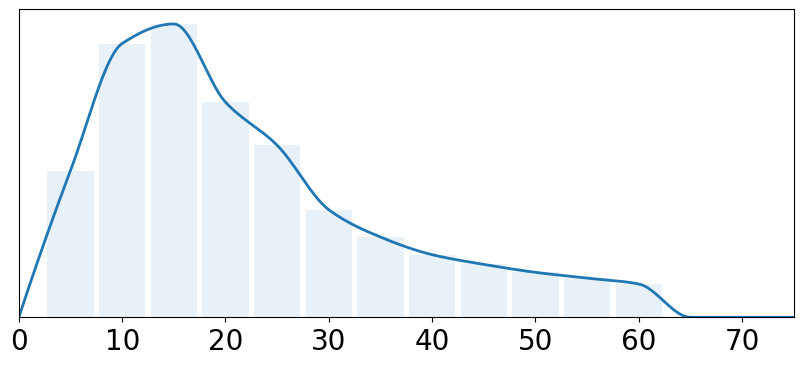

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

time = np.arange(0, 80, 5)
precip = np.array([0.0,5.302,9.897,10.604,7.777,6.219,3.887,2.901,2.262,1.911,1.624,1.415,1.203,0.0,0.0,0.0])

# Smooth interpolation
x_smooth = np.linspace(time.min(), time.max(), 400)
pchip = PchipInterpolator(time, precip)
y_smooth = pchip(x_smooth)

fig, ax = plt.subplots(figsize=(10,4))

# Bars and smooth curve
ax.bar(time, precip, width=4.5, align="center", alpha=0.1)
ax.plot(x_smooth, y_smooth, linewidth=2)

# Font size
label_fs = 20

ax.set_xlabel("", fontsize=label_fs)
ax.set_ylabel("", fontsize=label_fs)
ax.set_title("", fontsize=label_fs)

# Tick size for x-axis
ax.tick_params(axis="x", labelsize=label_fs)

# Remove y-axis ticks and numbers completely
ax.set_yticks([])

# Limits
ax.set_xlim(0, 75)

# Remove grid
ax.grid(False)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.show()

In [ ]:
### Figure one plotting 

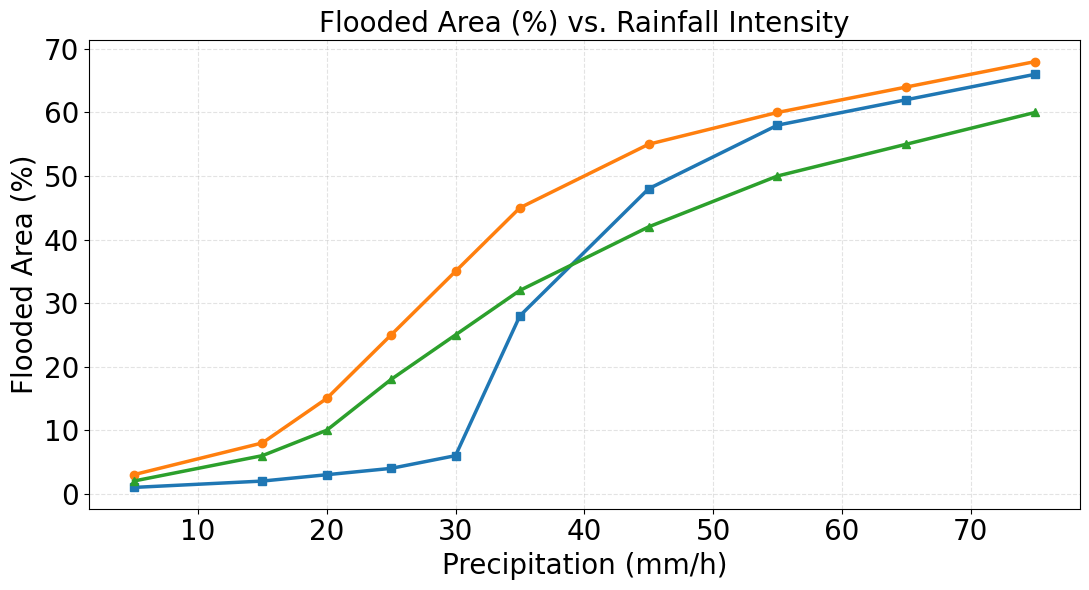

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Precipitation scenarios (mm/h)
x = np.array([5, 15, 20, 25, 30, 35, 45, 55, 65, 75])

# 1) Threshold behaviour: flat until ~30 mm/h, then sharp increase
threshold = np.array([1, 2, 3, 4, 6, 28, 48, 58, 62, 66])

# 2) Early response: starts increasing already around 20 mm/h
early = np.array([3, 8, 15, 25, 35, 45, 55, 60, 64, 68])

# 3) Gradual increase: smooth, concave behaviour
gradual = np.array([2, 6, 10, 18, 25, 32, 42, 50, 55, 60])

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(x, threshold, marker="s", linewidth=2.5, label="Morges")
ax.plot(x, early, marker="o", linewidth=2.5, label="Gordevio")
ax.plot(x, gradual, marker="^", linewidth=2.5, label="Sempach")

# Labels and title
ax.set_title("Flooded Area (%) vs. Rainfall Intensity", fontsize=20)
ax.set_xlabel("Precipitation (mm/h)", fontsize=20)
ax.set_ylabel("Flooded Area (%)", fontsize=20)

ax.tick_params(axis="both", labelsize=20)

# Light grid
ax.grid(True, linestyle="--", alpha=0.35)

# Legend
#ax.legend(loc="lower right", fontsize=12)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()
plt.show()


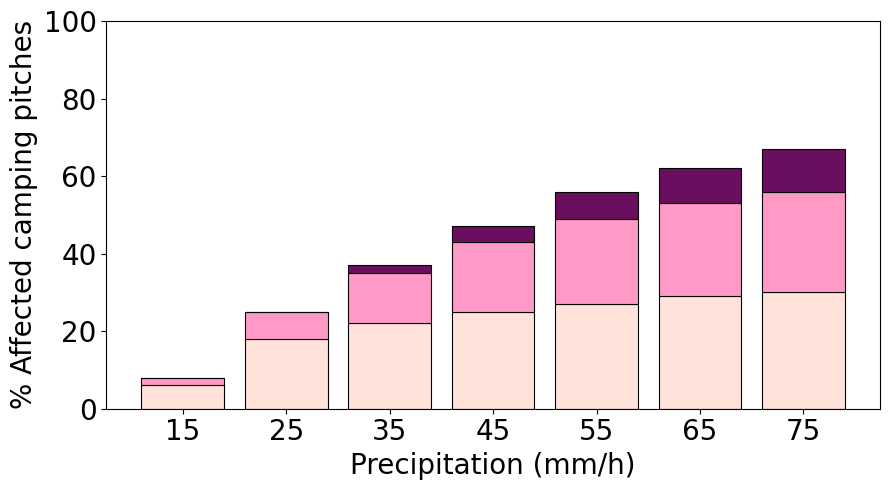

In [13]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([15, 25, 35, 45, 55, 65, 75])

depth_010_030 = np.array([6, 18, 22, 25, 27, 29, 30])
depth_gt_030  = np.array([2, 7, 13, 18, 22, 24, 26])
depth_gt_100  = np.array([0, 0, 2, 4, 7, 9, 11])

fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_alpha(0)
ax.set_facecolor("none")

colors = {
    "0.10–0.30 m (mobile)": "#FFE3DB",
    "> 0.30 m (mobile)":    "#FF9AC8",
    "> 1.00 m (non-mobile)": "#6A0F5F"
}

ax.bar(x, depth_010_030, width=8,
       color=colors["0.10–0.30 m (mobile)"],
       edgecolor="black", linewidth=0.8)

ax.bar(x, depth_gt_030, bottom=depth_010_030, width=8,
       color=colors["> 0.30 m (mobile)"],
       edgecolor="black", linewidth=0.8)

ax.bar(x, depth_gt_100,
       bottom=depth_010_030 + depth_gt_030,
       width=8,
       color=colors["> 1.00 m (non-mobile)"],
       edgecolor="black", linewidth=0.8)

ax.set_ylim(0, 100)
ax.set_xlabel("Precipitation (mm/h)", fontsize=20, color="black")
ax.set_ylabel("% Affected camping pitches", fontsize=20, color="black")

ax.tick_params(axis="both", colors="black", labelsize=20)

# 🔑 FORCE ticks to bar centers
ax.set_xticks(x)
ax.set_xticklabels(x)

for spine in ax.spines.values():
    spine.set_color("black")

ax.grid(False)

plt.tight_layout()
plt.show()


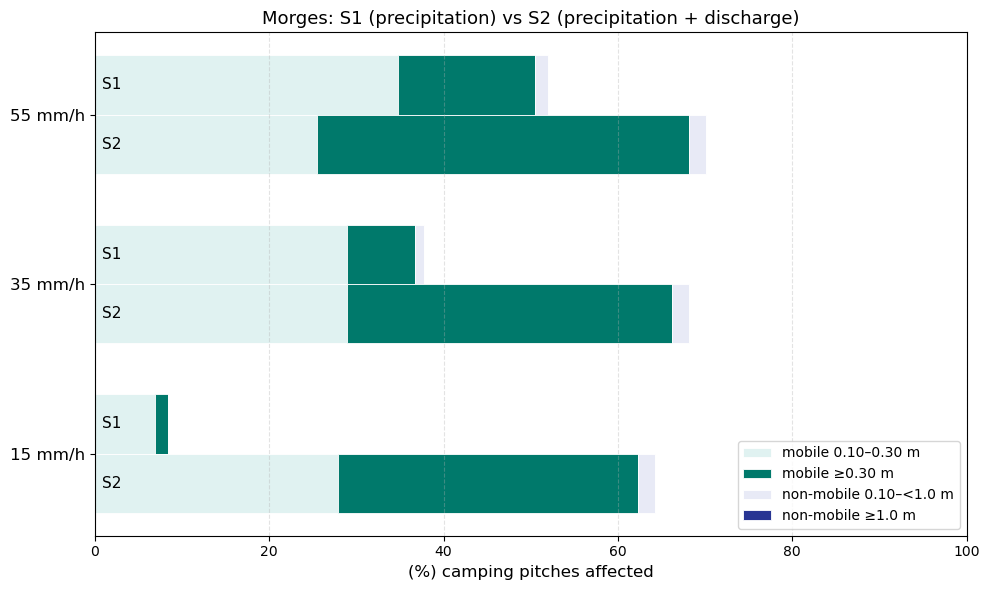

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
fractions_v2_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/fractions_long.csv"
fractions_v4_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v4/fractions_long.csv"

# Totals (same for both versions)
totals_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/Morges_2m_v2_exposure.xlsx"

versions_to_plot = ["v2", "v4"]
scenarios_to_plot = [15, 35, 55]

# Map internal versions -> figure labels
VERSION_LABELS = {
    "v2": "S1",
    "v4": "S2"
}

# --------------------------------------------------
# STACK ORDER + LABELS
# --------------------------------------------------
STACK_ORDER = [
    ("mobile", 1),
    ("mobile", 2),
    ("non_mobile", 1),
    ("non_mobile", 2),
]

LABELS = {
    ("mobile", 1):     "mobile 0.10–0.30 m",
    ("mobile", 2):     "mobile ≥0.30 m",
    ("non_mobile", 1): "non-mobile 0.10–<1.0 m",
    ("non_mobile", 2): "non-mobile ≥1.0 m",
}

# Professional teal/indigo color scheme
COLORS = {
    ("mobile", 1):     "#E0F2F1",
    ("mobile", 2):     "#00796B",
    ("non_mobile", 1): "#E8EAF6",
    ("non_mobile", 2): "#283593",
}

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
def read_totals(path):
    p = Path(path)
    if p.suffix.lower() == ".csv":
        t = pd.read_csv(p).iloc[0]
    else:
        t = pd.read_excel(p, sheet_name="site_totals").iloc[0]

    def safe_int(x):
        try:
            if pd.isna(x):
                return 0
            return int(x)
        except:
            return 0

    return (
        safe_int(t.get("mobile_total", 0)),
        safe_int(t.get("non_mobile_total", 0)),
    )

def fractions_to_pct_total(frac_long, totals):

    mobile_total, non_mobile_total = totals
    total_inventory = max(mobile_total + non_mobile_total, 1)

    def denom_for_group(g):
        g = str(g).lower()
        if g == "mobile":
            return mobile_total
        if g == "non_mobile":
            return non_mobile_total
        return 0

    df = frac_long.copy()
    denom = df["group"].map(denom_for_group)
    count = df["fraction"].astype(float) * denom
    df["pct_total"] = (count / total_inventory) * 100.0
    return df

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
v2 = pd.read_csv(fractions_v2_path)
v4 = pd.read_csv(fractions_v4_path)

frac_long = pd.concat([v2, v4], ignore_index=True)

# clean types
frac_long["version"] = frac_long["version"].astype(str).str.strip()
frac_long["group"] = frac_long["group"].astype(str).str.lower().str.strip()
frac_long["scenario"] = pd.to_numeric(frac_long["scenario"], errors="coerce")
frac_long["level"] = pd.to_numeric(frac_long["level"], errors="coerce")
frac_long["fraction"] = pd.to_numeric(frac_long["fraction"], errors="coerce")

frac_long = frac_long.dropna(subset=["scenario","level","fraction"])

frac_long["scenario"] = frac_long["scenario"].astype(int)
frac_long["level"] = frac_long["level"].astype(int)

# filter wanted versions + scenarios
frac_long = frac_long[
    frac_long["version"].isin(versions_to_plot) &
    frac_long["scenario"].isin(scenarios_to_plot)
].copy()

totals = read_totals(totals_path)
df = fractions_to_pct_total(frac_long, totals)

# build full grid (avoid missing bars)
idx = pd.MultiIndex.from_product(
    [versions_to_plot, scenarios_to_plot,
     [k[0] for k in STACK_ORDER],
     [k[1] for k in STACK_ORDER]],
    names=["version","scenario","group","level"]
)

df_full = (
    df.set_index(["version","scenario","group","level"])
      .reindex(idx, fill_value=0.0)
      .reset_index()
)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10,6))

bar_h = 0.35
ypos = np.arange(len(scenarios_to_plot))

offsets = {
    "v2": +bar_h/2,
    "v4": -bar_h/2,
}

for v in versions_to_plot:

    bottoms = np.zeros(len(scenarios_to_plot))

    for (g,l) in STACK_ORDER:

        vals = []

        for s in scenarios_to_plot:

            val = df_full.loc[
                (df_full.version==v) &
                (df_full.scenario==s) &
                (df_full.group==g) &
                (df_full.level==l),
                "pct_total"
            ].values

            vals.append(float(val[0]) if len(val) else 0.0)

        vals = np.array(vals)

        ax.barh(
            ypos + offsets[v],
            vals,
            left=bottoms,
            height=bar_h,
            color=COLORS[(g,l)],
            edgecolor="white",
            linewidth=0.6,
            label=LABELS[(g,l)] if v=="v2" else None
        )

        bottoms += vals

# y-axis labels
ax.set_yticks(ypos)
ax.set_yticklabels([f"{s} mm/h" for s in scenarios_to_plot], fontsize=12)

# version labels (S1 / S2)
for i in range(len(scenarios_to_plot)):
    for v in versions_to_plot:
        ax.text(
            0.8,
            ypos[i] + offsets[v],
            VERSION_LABELS.get(v, v),
            va="center",
            ha="left",
            fontsize=11
        )

ax.set_xlabel("(%) camping pitches affected", fontsize=12)
ax.set_xlim(0,100)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.legend(loc="lower right", frameon=True, fontsize=10)

ax.set_title("Morges: S1 (precipitation) vs S2 (precipitation + discharge)", fontsize=13)

fig.tight_layout()
plt.show()


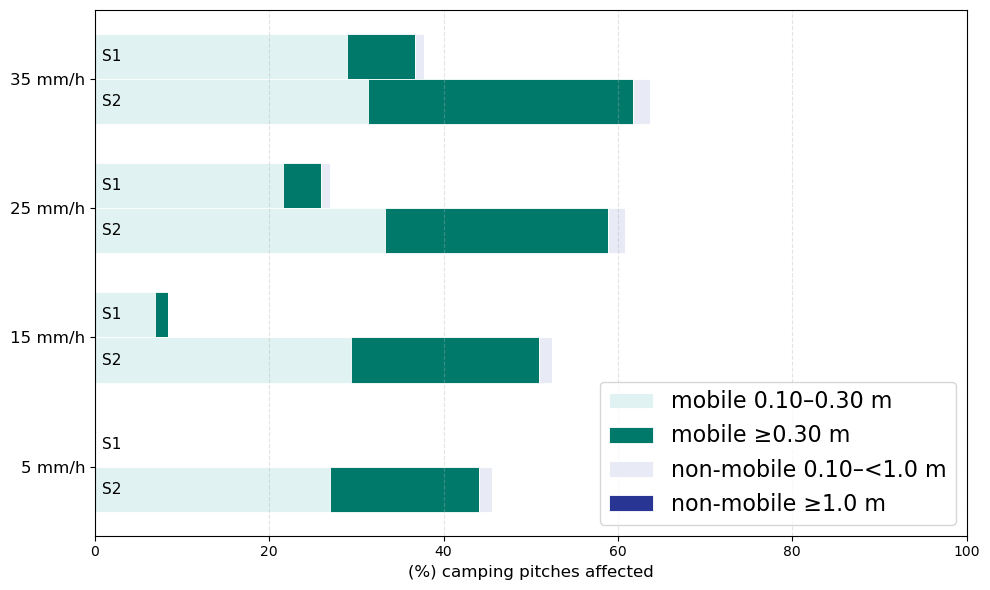

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
fractions_v2_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/fractions_long.csv"
fractions_v4_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v5/fractions_long.csv"

# Totals (same for both versions)
totals_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/Morges_2m_v2_exposure.xlsx"

versions_to_plot = ["v2", "v5"]
scenarios_to_plot = [5, 15, 25, 35]

# Map internal versions -> figure labels
VERSION_LABELS = {
    "v2": "S1",
    "v5": "S2"
}

# --------------------------------------------------
# STACK ORDER + LABELS
# --------------------------------------------------
STACK_ORDER = [
    ("mobile", 1),
    ("mobile", 2),
    ("non_mobile", 1),
    ("non_mobile", 2),
]

LABELS = {
    ("mobile", 1):     "mobile 0.10–0.30 m",
    ("mobile", 2):     "mobile ≥0.30 m",
    ("non_mobile", 1): "non-mobile 0.10–<1.0 m",
    ("non_mobile", 2): "non-mobile ≥1.0 m",
}

# Professional teal/indigo color scheme
COLORS = {
    ("mobile", 1):     "#E0F2F1",
    ("mobile", 2):     "#00796B",
    ("non_mobile", 1): "#E8EAF6",
    ("non_mobile", 2): "#283593",
}

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
def read_totals(path):
    p = Path(path)
    if p.suffix.lower() == ".csv":
        t = pd.read_csv(p).iloc[0]
    else:
        t = pd.read_excel(p, sheet_name="site_totals").iloc[0]

    def safe_int(x):
        try:
            if pd.isna(x):
                return 0
            return int(x)
        except:
            return 0

    return (
        safe_int(t.get("mobile_total", 0)),
        safe_int(t.get("non_mobile_total", 0)),
    )

def fractions_to_pct_total(frac_long, totals):

    mobile_total, non_mobile_total = totals
    total_inventory = max(mobile_total + non_mobile_total, 1)

    def denom_for_group(g):
        g = str(g).lower()
        if g == "mobile":
            return mobile_total
        if g == "non_mobile":
            return non_mobile_total
        return 0

    df = frac_long.copy()
    denom = df["group"].map(denom_for_group)
    count = df["fraction"].astype(float) * denom
    df["pct_total"] = (count / total_inventory) * 100.0
    return df

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
v2 = pd.read_csv(fractions_v2_path)
v4 = pd.read_csv(fractions_v4_path)

frac_long = pd.concat([v2, v4], ignore_index=True)

# clean types
frac_long["version"] = frac_long["version"].astype(str).str.strip()
frac_long["group"] = frac_long["group"].astype(str).str.lower().str.strip()
frac_long["scenario"] = pd.to_numeric(frac_long["scenario"], errors="coerce")
frac_long["level"] = pd.to_numeric(frac_long["level"], errors="coerce")
frac_long["fraction"] = pd.to_numeric(frac_long["fraction"], errors="coerce")

frac_long = frac_long.dropna(subset=["scenario","level","fraction"])

frac_long["scenario"] = frac_long["scenario"].astype(int)
frac_long["level"] = frac_long["level"].astype(int)

# filter wanted versions + scenarios
frac_long = frac_long[
    frac_long["version"].isin(versions_to_plot) &
    frac_long["scenario"].isin(scenarios_to_plot)
].copy()

totals = read_totals(totals_path)
df = fractions_to_pct_total(frac_long, totals)

# build full grid (avoid missing bars)
idx = pd.MultiIndex.from_product(
    [versions_to_plot, scenarios_to_plot,
     [k[0] for k in STACK_ORDER],
     [k[1] for k in STACK_ORDER]],
    names=["version","scenario","group","level"]
)

df_full = (
    df.set_index(["version","scenario","group","level"])
      .reindex(idx, fill_value=0.0)
      .reset_index()
)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10,6))

bar_h = 0.35
ypos = np.arange(len(scenarios_to_plot))

offsets = {
    "v2": +bar_h/2,
    "v5": -bar_h/2,
}

for v in versions_to_plot:

    bottoms = np.zeros(len(scenarios_to_plot))

    for (g,l) in STACK_ORDER:

        vals = []

        for s in scenarios_to_plot:

            val = df_full.loc[
                (df_full.version==v) &
                (df_full.scenario==s) &
                (df_full.group==g) &
                (df_full.level==l),
                "pct_total"
            ].values

            vals.append(float(val[0]) if len(val) else 0.0)

        vals = np.array(vals)

        ax.barh(
            ypos + offsets[v],
            vals,
            left=bottoms,
            height=bar_h,
            color=COLORS[(g,l)],
            edgecolor="white",
            linewidth=0.6,
            label=LABELS[(g,l)] if v=="v2" else None
        )

        bottoms += vals

# y-axis labels
ax.set_yticks(ypos)
ax.set_yticklabels([f"{s} mm/h" for s in scenarios_to_plot], fontsize=12)

# version labels (S1 / S2)
for i in range(len(scenarios_to_plot)):
    for v in versions_to_plot:
        ax.text(
            0.8,
            ypos[i] + offsets[v],
            VERSION_LABELS.get(v, v),
            va="center",
            ha="left",
            fontsize=11
        )

ax.set_xlabel("(%) camping pitches affected", fontsize=12)
ax.set_xlim(0,100)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.legend(loc="lower right", frameon=True, fontsize=16)

ax.set_title("", fontsize=13)

fig.tight_layout()
plt.show()

In [ ]:
############# Combiprecip 

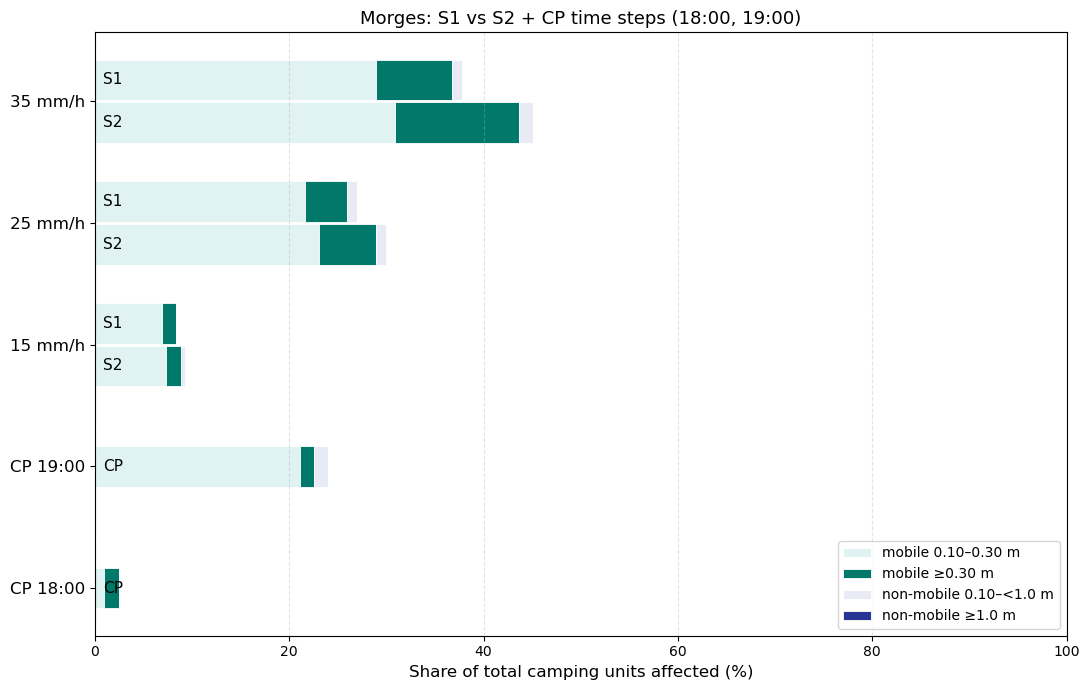

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
fractions_v2_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/fractions_long.csv"
fractions_v4_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v4/fractions_long.csv"

# CP counts (from NetCDF time steps)
cp_counts_long_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_CP/MORGES_CP_counts_long.csv"
cp_times_to_plot = ["18:00", "19:00"]  # add more if you want (e.g., ["18:00","19:00","20:00","21:00"])

# Totals (same denominator for all)
totals_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/Morges_2m_v2_exposure.xlsx"

versions_to_plot = ["v2", "v4"]
scenarios_to_plot = [15,25,35]

# Map internal versions -> figure labels
VERSION_LABELS = {
    "v2": "S1",
    "v4": "S2",
}

# --------------------------------------------------
# STACK ORDER + LABELS
# --------------------------------------------------
STACK_ORDER = [
    ("mobile", 1),
    ("mobile", 2),
    ("non_mobile", 1),
    ("non_mobile", 2),
]

LABELS = {
    ("mobile", 1):     "mobile 0.10–0.30 m",
    ("mobile", 2):     "mobile ≥0.30 m",
    ("non_mobile", 1): "non-mobile 0.10–<1.0 m",
    ("non_mobile", 2): "non-mobile ≥1.0 m",
}

# Professional teal/indigo color scheme
COLORS = {
    ("mobile", 1):     "#E0F2F1",
    ("mobile", 2):     "#00796B",
    ("non_mobile", 1): "#E8EAF6",
    ("non_mobile", 2): "#283593",
}

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
def read_totals(path):
    p = Path(path)
    if p.suffix.lower() == ".csv":
        t = pd.read_csv(p).iloc[0]
    else:
        t = pd.read_excel(p, sheet_name="site_totals").iloc[0]

    def safe_int(x):
        try:
            if pd.isna(x):
                return 0
            return int(x)
        except Exception:
            return 0

    return (
        safe_int(t.get("mobile_total", 0)),
        safe_int(t.get("non_mobile_total", 0)),
    )

def fractions_to_pct_total(frac_long, totals):
    mobile_total, non_mobile_total = totals
    total_inventory = max(mobile_total + non_mobile_total, 1)

    def denom_for_group(g):
        g = str(g).lower().strip()
        if g == "mobile":
            return mobile_total
        if g == "non_mobile":
            return non_mobile_total
        return 0

    df = frac_long.copy()
    df["group"] = df["group"].astype(str).str.lower().str.strip()
    denom = df["group"].map(denom_for_group).astype(float)
    count = df["fraction"].astype(float) * denom
    df["pct_total"] = (count / total_inventory) * 100.0
    return df

def load_cp_pct_total(cp_counts_long_path, totals, cp_times_to_plot):
    """Return CP stacked values (% of total inventory) for requested clock times like '18:00'."""
    mobile_total, non_mobile_total = totals
    total_inventory = max(mobile_total + non_mobile_total, 1)

    cp = pd.read_csv(cp_counts_long_path)
    cp["time"] = pd.to_datetime(cp["time"])
    cp["group"] = cp["group"].astype(str).str.lower().str.strip()
    cp["level"] = pd.to_numeric(cp["level"], errors="coerce").astype("Int64")
    cp["count"] = pd.to_numeric(cp["count"], errors="coerce").fillna(0.0)

    # keep only expected combos
    cp = cp[cp["group"].isin(["mobile","non_mobile"]) & cp["level"].isin([1,2])].copy()

    cp["pct_total"] = (cp["count"] / total_inventory) * 100.0
    cp["clock"] = cp["time"].dt.strftime("%H:%M")
    cp["cat"] = cp["group"] + "_" + cp["level"].astype(int).astype(str)

    # pivot per timestamp
    wide = (cp.pivot_table(index="time", columns="cat", values="pct_total", aggfunc="sum", fill_value=0.0)
              .sort_index())

    # ensure all columns exist
    for c in ["mobile_1", "mobile_2", "non_mobile_1", "non_mobile_2"]:
        if c not in wide.columns:
            wide[c] = 0.0
    wide = wide[["mobile_1","mobile_2","non_mobile_1","non_mobile_2"]]

    # pick rows by clock-time: if multiple dates, take the first occurrence per clock
    out = {}
    for clk in cp_times_to_plot:
        candidates = wide[wide.index.strftime("%H:%M") == clk]
        if candidates.empty:
            # if exact clock not found, skip
            out[clk] = None
        else:
            out[clk] = candidates.iloc[0]  # first occurrence
    return out

# --------------------------------------------------
# LOAD SCENARIO DATA (v2/v4 fractions_long)
# --------------------------------------------------
v2 = pd.read_csv(fractions_v2_path)
v4 = pd.read_csv(fractions_v4_path)
frac_long = pd.concat([v2, v4], ignore_index=True)

# clean types
frac_long["version"] = frac_long["version"].astype(str).str.strip()
frac_long["group"] = frac_long["group"].astype(str).str.lower().str.strip()
frac_long["scenario"] = pd.to_numeric(frac_long["scenario"], errors="coerce")
frac_long["level"] = pd.to_numeric(frac_long["level"], errors="coerce")
frac_long["fraction"] = pd.to_numeric(frac_long["fraction"], errors="coerce")
frac_long = frac_long.dropna(subset=["scenario","level","fraction"])

frac_long["scenario"] = frac_long["scenario"].astype(int)
frac_long["level"] = frac_long["level"].astype(int)

# filter wanted versions + scenarios
frac_long = frac_long[
    frac_long["version"].isin(versions_to_plot) &
    frac_long["scenario"].isin(scenarios_to_plot)
].copy()

totals = read_totals(totals_path)
df = fractions_to_pct_total(frac_long, totals)

# build full grid (avoid missing bars)
idx = pd.MultiIndex.from_product(
    [versions_to_plot, scenarios_to_plot,
     [k[0] for k in STACK_ORDER],
     [k[1] for k in STACK_ORDER]],
    names=["version","scenario","group","level"]
)

df_full = (
    df.set_index(["version","scenario","group","level"])
      .reindex(idx, fill_value=0.0)
      .reset_index()
)

# --------------------------------------------------
# LOAD CP (time steps) and convert to % total
# --------------------------------------------------
cp_rows = load_cp_pct_total(cp_counts_long_path, totals, cp_times_to_plot)

# --------------------------------------------------
# BUILD Y-AXIS ROWS: CP rows above scenario rows
# --------------------------------------------------
row_labels = [f"CP {t}" for t in cp_times_to_plot] + [f"{s} mm/h" for s in scenarios_to_plot]
ypos = np.arange(len(row_labels))

# map each scenario row index
scenario_row_start = len(cp_times_to_plot)
scenario_to_y = {s: scenario_row_start + i for i, s in enumerate(scenarios_to_plot)}

# map CP row index
cp_to_y = {t: i for i, t in enumerate(cp_times_to_plot)}

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))

bar_h = 0.35

# Offsets for S1/S2 on scenario rows
offsets = {
    "v2": +bar_h/2,
    "v4": -bar_h/2,
}

# --- plot S1/S2 for scenario rows ---
for v in versions_to_plot:
    for s in scenarios_to_plot:
        y = scenario_to_y[s] + offsets[v]
        bottoms = 0.0

        for (g, l) in STACK_ORDER:
            val = df_full.loc[
                (df_full.version == v) &
                (df_full.scenario == s) &
                (df_full.group == g) &
                (df_full.level == l),
                "pct_total"
            ].values

            width = float(val[0]) if len(val) else 0.0

            ax.barh(
                y,
                width,
                left=bottoms,
                height=bar_h * 0.95,
                color=COLORS[(g, l)],
                edgecolor="white",
                linewidth=0.6,
                label=LABELS[(g, l)] if v == "v2" and s == scenarios_to_plot[0] else None
            )
            bottoms += width

        # label S1/S2 near bar start
        ax.text(
            0.8, y,
            VERSION_LABELS.get(v, v),
            va="center", ha="left",
            fontsize=11
        )

# --- plot CP rows (single centered bar per time) ---
for t in cp_times_to_plot:
    series = cp_rows.get(t, None)
    y = cp_to_y[t]  # no offset (single bar)

    if series is None:
        # still print label and continue
        ax.text(1.5, y, "no data", va="center", ha="left", fontsize=10)
        continue

    bottoms = 0.0
    # series columns: mobile_1, mobile_2, non_mobile_1, non_mobile_2
    lookup = {
        ("mobile", 1): float(series["mobile_1"]),
        ("mobile", 2): float(series["mobile_2"]),
        ("non_mobile", 1): float(series["non_mobile_1"]),
        ("non_mobile", 2): float(series["non_mobile_2"]),
    }

    for (g, l) in STACK_ORDER:
        width = lookup[(g, l)]
        ax.barh(
            y,
            width,
            left=bottoms,
            height=bar_h * 0.95,
            color=COLORS[(g, l)],
            edgecolor="white",
            linewidth=0.6,
        )
        bottoms += width

    # label "CP" near bar start
    ax.text(0.8, y, "CP", va="center", ha="left", fontsize=11)

# y-axis labels
ax.set_yticks(ypos)
ax.set_yticklabels(row_labels, fontsize=12)

ax.set_xlabel("Share of total camping units affected (%)", fontsize=12)
ax.set_xlim(0, 100)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.legend(loc="lower right", frameon=True, fontsize=10)

ax.set_title("Morges: S1 vs S2 + CP time steps (18:00, 19:00)", fontsize=13)

fig.tight_layout()
plt.show()

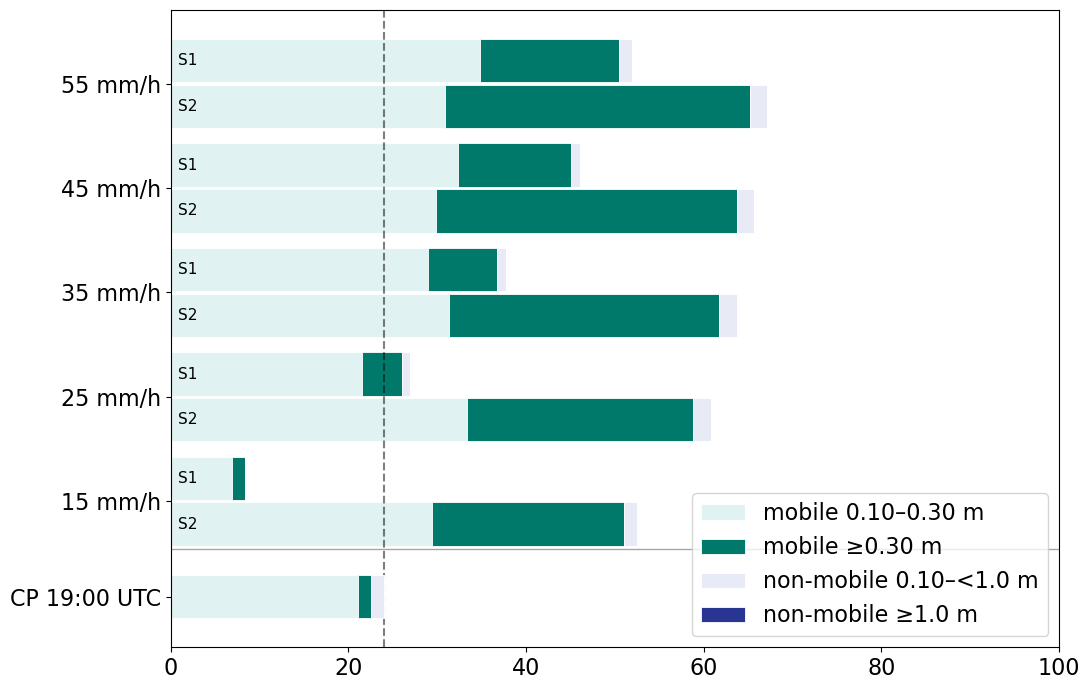

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
fractions_v2_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/fractions_long.csv"
fractions_v4_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v5/fractions_long.csv"

# CP counts (from NetCDF time steps)
cp_counts_long_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_CP/MORGES_CP_counts_long.csv"
cp_times_to_plot = ["19:00"]  # e.g. ["18:00","19:00"]

# Totals (same denominator for all)
totals_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/Morges_2m_v2_exposure.xlsx"

versions_to_plot = ["v2", "v5"]
scenarios_to_plot = [15, 25, 35,45,55]

# Map internal versions -> figure labels
VERSION_LABELS = {
    "v2": "S1",
    "v5": "S2",
}

# --------------------------------------------------
# STACK ORDER + LABELS
# --------------------------------------------------
STACK_ORDER = [
    ("mobile", 1),
    ("mobile", 2),
    ("non_mobile", 1),
    ("non_mobile", 2),
]

LABELS = {
    ("mobile", 1):     "mobile 0.10–0.30 m",
    ("mobile", 2):     "mobile ≥0.30 m",
    ("non_mobile", 1): "non-mobile 0.10–<1.0 m",
    ("non_mobile", 2): "non-mobile ≥1.0 m",
}

# Color scheme (teal / indigo)
COLORS = {
    ("mobile", 1):     "#E0F2F1",
    ("mobile", 2):     "#00796B",
    ("non_mobile", 1): "#E8EAF6",
    ("non_mobile", 2): "#283593",
}

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
def read_totals(path):
    p = Path(path)
    if p.suffix.lower() == ".csv":
        t = pd.read_csv(p).iloc[0]
    else:
        t = pd.read_excel(p, sheet_name="site_totals").iloc[0]

    def safe_int(x):
        try:
            if pd.isna(x):
                return 0
            return int(x)
        except Exception:
            return 0

    return (
        safe_int(t.get("mobile_total", 0)),
        safe_int(t.get("non_mobile_total", 0)),
    )

def fractions_to_pct_total(frac_long, totals):
    mobile_total, non_mobile_total = totals
    total_inventory = max(mobile_total + non_mobile_total, 1)

    def denom_for_group(g):
        g = str(g).lower().strip()
        if g == "mobile":
            return mobile_total
        if g == "non_mobile":
            return non_mobile_total
        return 0

    df = frac_long.copy()
    df["group"] = df["group"].astype(str).str.lower().str.strip()
    denom = df["group"].map(denom_for_group).astype(float)
    count = df["fraction"].astype(float) * denom
    df["pct_total"] = (count / total_inventory) * 100.0
    return df

def load_cp_pct_total(cp_counts_long_path, totals, cp_times_to_plot):
    """Return CP stacked values (% of total inventory) for requested clock times like '19:00'."""
    mobile_total, non_mobile_total = totals
    total_inventory = max(mobile_total + non_mobile_total, 1)

    cp = pd.read_csv(cp_counts_long_path)
    cp["time"] = pd.to_datetime(cp["time"])
    cp["group"] = cp["group"].astype(str).str.lower().str.strip()
    cp["level"] = pd.to_numeric(cp["level"], errors="coerce").astype("Int64")
    cp["count"] = pd.to_numeric(cp["count"], errors="coerce").fillna(0.0)

    # keep only expected combos
    cp = cp[cp["group"].isin(["mobile", "non_mobile"]) & cp["level"].isin([1, 2])].copy()

    cp["pct_total"] = (cp["count"] / total_inventory) * 100.0
    cp["clock"] = cp["time"].dt.strftime("%H:%M")
    cp["cat"] = cp["group"] + "_" + cp["level"].astype(int).astype(str)

    wide = (cp.pivot_table(index="time", columns="cat", values="pct_total",
                           aggfunc="sum", fill_value=0.0)
              .sort_index())

    for c in ["mobile_1", "mobile_2", "non_mobile_1", "non_mobile_2"]:
        if c not in wide.columns:
            wide[c] = 0.0
    wide = wide[["mobile_1", "mobile_2", "non_mobile_1", "non_mobile_2"]]

    out = {}
    for clk in cp_times_to_plot:
        candidates = wide[wide.index.strftime("%H:%M") == clk]
        out[clk] = None if candidates.empty else candidates.iloc[0]  # first occurrence
    return out

# --------------------------------------------------
# LOAD SCENARIO DATA (v2/v4 fractions_long)
# --------------------------------------------------
v2 = pd.read_csv(fractions_v2_path)
v4 = pd.read_csv(fractions_v4_path)
frac_long = pd.concat([v2, v4], ignore_index=True)

# clean types
frac_long["version"] = frac_long["version"].astype(str).str.strip()
frac_long["group"] = frac_long["group"].astype(str).str.lower().str.strip()
frac_long["scenario"] = pd.to_numeric(frac_long["scenario"], errors="coerce")
frac_long["level"] = pd.to_numeric(frac_long["level"], errors="coerce")
frac_long["fraction"] = pd.to_numeric(frac_long["fraction"], errors="coerce")
frac_long = frac_long.dropna(subset=["scenario", "level", "fraction"])

frac_long["scenario"] = frac_long["scenario"].astype(int)
frac_long["level"] = frac_long["level"].astype(int)

# filter wanted versions + scenarios
frac_long = frac_long[
    frac_long["version"].isin(versions_to_plot) &
    frac_long["scenario"].isin(scenarios_to_plot)
].copy()

totals = read_totals(totals_path)
df = fractions_to_pct_total(frac_long, totals)

# build full grid (avoid missing bars)
idx = pd.MultiIndex.from_product(
    [
        versions_to_plot,
        scenarios_to_plot,
        [k[0] for k in STACK_ORDER],
        [k[1] for k in STACK_ORDER],
    ],
    names=["version", "scenario", "group", "level"]
)

df_full = (
    df.set_index(["version", "scenario", "group", "level"])
      .reindex(idx, fill_value=0.0)
      .reset_index()
)

# --------------------------------------------------
# LOAD CP (time steps) and convert to % total
# --------------------------------------------------
cp_rows = load_cp_pct_total(cp_counts_long_path, totals, cp_times_to_plot)

# --------------------------------------------------
# BUILD Y-AXIS ROWS: compact layout (smaller gap CP <-> scenarios)
# --------------------------------------------------
cp_gap = 0.38
block_gap = 0.35
scenario_gap = 0.80

cp_positions = [i * cp_gap for i in range(len(cp_times_to_plot))]
scenario_start = cp_positions[-1] + cp_gap + block_gap
scenario_positions = [scenario_start + i * scenario_gap for i in range(len(scenarios_to_plot))]
sep_y = (cp_positions[-1] + scenario_start) / 2

row_labels = [f"CP {t} UTC" for t in cp_times_to_plot] + [f"{s} mm/h" for s in scenarios_to_plot]
ypos = np.array(cp_positions + scenario_positions)

scenario_to_y = {s: scenario_positions[i] for i, s in enumerate(scenarios_to_plot)}
cp_to_y = {t: cp_positions[i] for i, t in enumerate(cp_times_to_plot)}

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))

# transparent background (figure + axes)
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

bar_h = 0.35

# Offsets for S1/S2 on scenario rows
offsets = {"v2": +bar_h/2, "v5": -bar_h/2}

# --- plot S1/S2 for scenario rows ---
for v in versions_to_plot:
    for s in scenarios_to_plot:
        y = scenario_to_y[s] + offsets[v]
        bottoms = 0.0

        for (g, l) in STACK_ORDER:
            val = df_full.loc[
                (df_full.version == v) &
                (df_full.scenario == s) &
                (df_full.group == g) &
                (df_full.level == l),
                "pct_total"
            ].values

            width = float(val[0]) if len(val) else 0.0

            ax.barh(
                y,
                width,
                left=bottoms,
                height=bar_h * 0.95,
                color=COLORS[(g, l)],
                edgecolor="white",
                linewidth=0.6,
                label=LABELS[(g, l)] if v == "v2" and s == scenarios_to_plot[0] else None
            )
            bottoms += width

        ax.text(0.8, y, VERSION_LABELS.get(v, v), va="center", ha="left", fontsize=11)

# --- plot CP rows (single centered bar per time) ---
for t in cp_times_to_plot:
    series = cp_rows.get(t, None)
    y = cp_to_y[t]

    if series is None:
        ax.text(1.5, y, "no data", va="center", ha="left", fontsize=10)
        continue

    lookup = {
        ("mobile", 1): float(series["mobile_1"]),
        ("mobile", 2): float(series["mobile_2"]),
        ("non_mobile", 1): float(series["non_mobile_1"]),
        ("non_mobile", 2): float(series["non_mobile_2"]),
    }

    # --- cumulative end position for each stacked segment
    stack_pos = {}
    cum = 0.0
    for key in STACK_ORDER:
        cum += lookup[key]
        stack_pos[key] = cum

    # --- FULL-HEIGHT dashed line at the END of the chosen CP segment
    # Choose which segment you want:
    #   ("mobile", 1)     -> end of mobile 0.10–0.30
    #   ("mobile", 2)     -> end of mobile ≥0.30
    #   ("non_mobile", 1) -> end of non-mobile 0.10–<1.0
    #   ("non_mobile", 2) -> end of non-mobile ≥1.0
    if t == "19:00":
        xline = stack_pos[("non_mobile", 1)]   # <<< change this if you want another boundary
        ax.axvline(x=xline,linestyle="--",linewidth=1.5,color="black",alpha=0.5,zorder=1)

    # plot the stacked CP bar
    bottoms = 0.0
    for (g, l) in STACK_ORDER:
        width = lookup[(g, l)]
        ax.barh(
            y,
            width,
            left=bottoms,
            height=bar_h * 0.95,
            color=COLORS[(g, l)],
            edgecolor="white",
            linewidth=0.6,
        )
        bottoms += width

# separator line between CP block and scenarios
ax.axhline(sep_y, color="black", linewidth=1.0, alpha=0.35)

# y-axis labels
ax.set_yticks(ypos)
ax.set_yticklabels(row_labels, fontsize=16)

ax.set_xlabel("", fontsize=16)
ax.set_xlim(0, 100)
ax.tick_params(axis='x', labelsize=16) 

# remove vertical grid lines
ax.grid(False)

ax.legend(loc="lower right", frameon=True, fontsize=16)
ax.set_title("", fontsize=13)

fig.tight_layout()
plt.show()

# If you save it:
fig.savefig("/storage/homefs/ge24z347/LISFLOOD_FP_outputs/Morges_2m_scenarios/Morges_shareofaffected_S1_S2_CP.jpg", dpi=300, transparent=True, bbox_inches="tight")

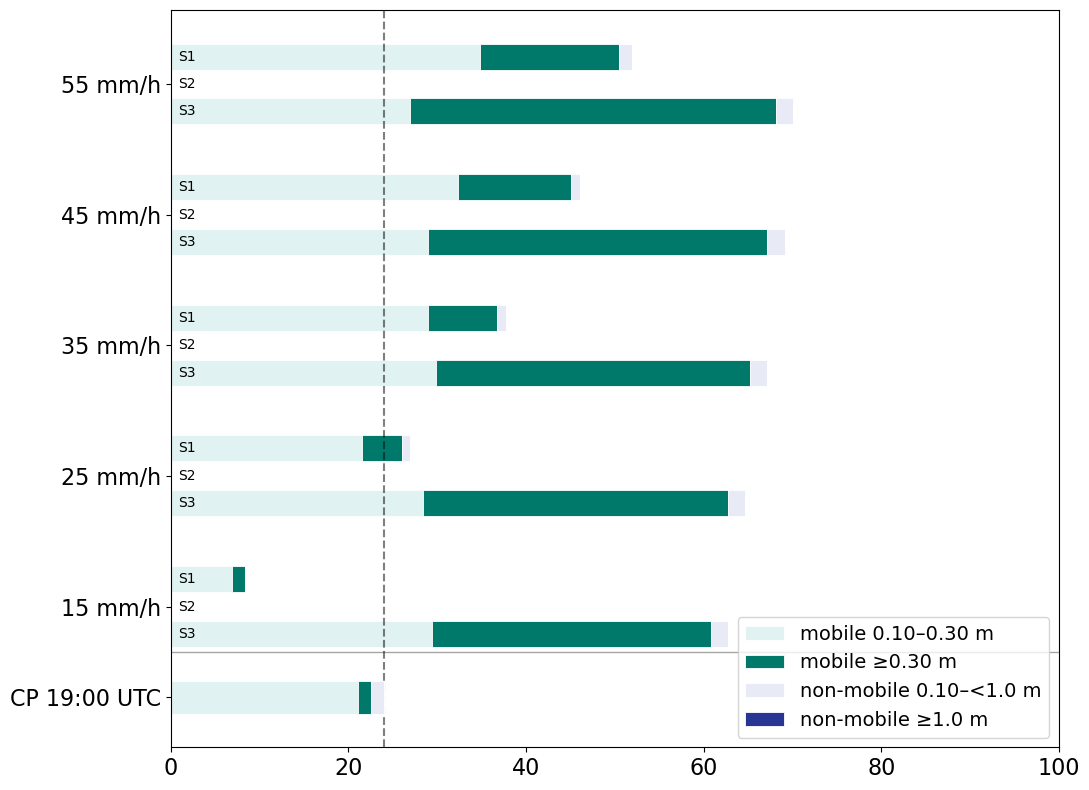

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
fractions_v2_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/fractions_long.csv"
fractions_v4_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v5/fractions_long.csv" 
fractions_v5_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v6/fractions_long.csv"

# CP counts (from NetCDF time steps)
cp_counts_long_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_CP/MORGES_CP_counts_long.csv"
cp_times_to_plot = ["19:00"]  # e.g. ["18:00","19:00"]

# Totals (same denominator for all)
totals_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v2/Morges_2m_v2_exposure.xlsx"

# Three scenario versions to compare
versions_to_plot = ["v2", "v4", "v5"]
scenarios_to_plot = [15, 25, 35, 45, 55]

# Map internal versions -> figure labels
VERSION_LABELS = {
    "v2": "S1",
    "v4": "S2",
    "v5": "S3",
}

# --------------------------------------------------
# STACK ORDER + LABELS
# --------------------------------------------------
STACK_ORDER = [
    ("mobile", 1),
    ("mobile", 2),
    ("non_mobile", 1),
    ("non_mobile", 2),
]

LABELS = {
    ("mobile", 1):     "mobile 0.10–0.30 m",
    ("mobile", 2):     "mobile ≥0.30 m",
    ("non_mobile", 1): "non-mobile 0.10–<1.0 m",
    ("non_mobile", 2): "non-mobile ≥1.0 m",
}

# Color scheme (teal / indigo)
COLORS = {
    ("mobile", 1):     "#E0F2F1",
    ("mobile", 2):     "#00796B",
    ("non_mobile", 1): "#E8EAF6",
    ("non_mobile", 2): "#283593",
}

# --------------------------------------------------
# HELPERS
# --------------------------------------------------
def read_totals(path):
    p = Path(path)
    if p.suffix.lower() == ".csv":
        t = pd.read_csv(p).iloc[0]
    else:
        t = pd.read_excel(p, sheet_name="site_totals").iloc[0]

    def safe_int(x):
        try:
            if pd.isna(x):
                return 0
            return int(x)
        except Exception:
            return 0

    return (
        safe_int(t.get("mobile_total", 0)),
        safe_int(t.get("non_mobile_total", 0)),
    )

def fractions_to_pct_total(frac_long, totals):
    mobile_total, non_mobile_total = totals
    total_inventory = max(mobile_total + non_mobile_total, 1)

    def denom_for_group(g):
        g = str(g).lower().strip()
        if g == "mobile":
            return mobile_total
        if g == "non_mobile":
            return non_mobile_total
        return 0

    df = frac_long.copy()
    df["group"] = df["group"].astype(str).str.lower().str.strip()
    denom = df["group"].map(denom_for_group).astype(float)
    count = df["fraction"].astype(float) * denom
    df["pct_total"] = (count / total_inventory) * 100.0
    return df

def load_cp_pct_total(cp_counts_long_path, totals, cp_times_to_plot):
    """Return CP stacked values (% of total inventory) for requested clock times like '19:00'."""
    mobile_total, non_mobile_total = totals
    total_inventory = max(mobile_total + non_mobile_total, 1)

    cp = pd.read_csv(cp_counts_long_path)
    cp["time"] = pd.to_datetime(cp["time"])
    cp["group"] = cp["group"].astype(str).str.lower().str.strip()
    cp["level"] = pd.to_numeric(cp["level"], errors="coerce").astype("Int64")
    cp["count"] = pd.to_numeric(cp["count"], errors="coerce").fillna(0.0)

    # keep only expected combos
    cp = cp[cp["group"].isin(["mobile", "non_mobile"]) & cp["level"].isin([1, 2])].copy()

    cp["pct_total"] = (cp["count"] / total_inventory) * 100.0
    cp["clock"] = cp["time"].dt.strftime("%H:%M")
    cp["cat"] = cp["group"] + "_" + cp["level"].astype(int).astype(str)

    wide = (cp.pivot_table(index="time", columns="cat", values="pct_total",
                           aggfunc="sum", fill_value=0.0)
              .sort_index())

    for c in ["mobile_1", "mobile_2", "non_mobile_1", "non_mobile_2"]:
        if c not in wide.columns:
            wide[c] = 0.0
    wide = wide[["mobile_1", "mobile_2", "non_mobile_1", "non_mobile_2"]]

    out = {}
    for clk in cp_times_to_plot:
        candidates = wide[wide.index.strftime("%H:%M") == clk]
        out[clk] = None if candidates.empty else candidates.iloc[0]
    return out

# --------------------------------------------------
# LOAD SCENARIO DATA (3 versions)
# --------------------------------------------------
v2 = pd.read_csv(fractions_v2_path)
v4 = pd.read_csv(fractions_v4_path)
v5 = pd.read_csv(fractions_v5_path)

frac_long = pd.concat([v2, v4, v5], ignore_index=True)

# clean types
frac_long["version"] = frac_long["version"].astype(str).str.strip()
frac_long["group"] = frac_long["group"].astype(str).str.lower().str.strip()
frac_long["scenario"] = pd.to_numeric(frac_long["scenario"], errors="coerce")
frac_long["level"] = pd.to_numeric(frac_long["level"], errors="coerce")
frac_long["fraction"] = pd.to_numeric(frac_long["fraction"], errors="coerce")
frac_long = frac_long.dropna(subset=["scenario", "level", "fraction"])

frac_long["scenario"] = frac_long["scenario"].astype(int)
frac_long["level"] = frac_long["level"].astype(int)

# filter wanted versions + scenarios
frac_long = frac_long[
    frac_long["version"].isin(versions_to_plot) &
    frac_long["scenario"].isin(scenarios_to_plot)
].copy()

totals = read_totals(totals_path)
df = fractions_to_pct_total(frac_long, totals)

# build full grid (avoid missing bars)
idx = pd.MultiIndex.from_product(
    [
        versions_to_plot,
        scenarios_to_plot,
        [k[0] for k in STACK_ORDER],
        [k[1] for k in STACK_ORDER],
    ],
    names=["version", "scenario", "group", "level"]
)

df_full = (
    df.set_index(["version", "scenario", "group", "level"])
      .reindex(idx, fill_value=0.0)
      .reset_index()
)

# --------------------------------------------------
# LOAD CP (time steps) and convert to % total
# --------------------------------------------------
cp_rows = load_cp_pct_total(cp_counts_long_path, totals, cp_times_to_plot)

# --------------------------------------------------
# BUILD Y-AXIS ROWS
# --------------------------------------------------
cp_gap = 0.38
block_gap = 0.35
scenario_gap = 1.05   # larger gap because now 3 bars per rainfall row

cp_positions = [i * cp_gap for i in range(len(cp_times_to_plot))]
scenario_start = cp_positions[-1] + cp_gap + block_gap
scenario_positions = [scenario_start + i * scenario_gap for i in range(len(scenarios_to_plot))]
sep_y = (cp_positions[-1] + scenario_start) / 2

row_labels = [f"CP {t} UTC" for t in cp_times_to_plot] + [f"{s} mm/h" for s in scenarios_to_plot]
ypos = np.array(cp_positions + scenario_positions)

scenario_to_y = {s: scenario_positions[i] for i, s in enumerate(scenarios_to_plot)}
cp_to_y = {t: cp_positions[i] for i, t in enumerate(cp_times_to_plot)}

# --------------------------------------------------
# PLOT
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 8))

# transparent background
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# smaller bar height for 3 stacked-version rows
bar_h = 0.22

# automatic offsets for 3 versions
offset_values = np.linspace(bar_h, -bar_h, len(versions_to_plot))
offsets = dict(zip(versions_to_plot, offset_values))

# --- plot S1/S2/S3 for scenario rows ---
for v in versions_to_plot:
    for s in scenarios_to_plot:
        y = scenario_to_y[s] + offsets[v]
        bottoms = 0.0

        for (g, l) in STACK_ORDER:
            val = df_full.loc[
                (df_full.version == v) &
                (df_full.scenario == s) &
                (df_full.group == g) &
                (df_full.level == l),
                "pct_total"
            ].values

            width = float(val[0]) if len(val) else 0.0

            ax.barh(
                y,
                width,
                left=bottoms,
                height=bar_h * 0.95,
                color=COLORS[(g, l)],
                edgecolor="white",
                linewidth=0.6,
                label=LABELS[(g, l)] if (v == versions_to_plot[0] and s == scenarios_to_plot[0]) else None
            )
            bottoms += width

        ax.text(0.8, y, VERSION_LABELS.get(v, v), va="center", ha="left", fontsize=10)

# --- plot CP rows (single centered bar per time) ---
for t in cp_times_to_plot:
    series = cp_rows.get(t, None)
    y = cp_to_y[t]

    if series is None:
        ax.text(1.5, y, "no data", va="center", ha="left", fontsize=10)
        continue

    lookup = {
        ("mobile", 1): float(series["mobile_1"]),
        ("mobile", 2): float(series["mobile_2"]),
        ("non_mobile", 1): float(series["non_mobile_1"]),
        ("non_mobile", 2): float(series["non_mobile_2"]),
    }

    # cumulative end position for each stacked segment
    stack_pos = {}
    cum = 0.0
    for key in STACK_ORDER:
        cum += lookup[key]
        stack_pos[key] = cum

    if t == "19:00":
        xline = stack_pos[("non_mobile", 1)]
        ax.axvline(
            x=xline,
            linestyle="--",
            linewidth=1.5,
            color="black",
            alpha=0.5,
            zorder=1
        )

    bottoms = 0.0
    for (g, l) in STACK_ORDER:
        width = lookup[(g, l)]
        ax.barh(
            y,
            width,
            left=bottoms,
            height=bar_h * 1.2,
            color=COLORS[(g, l)],
            edgecolor="white",
            linewidth=0.6,
        )
        bottoms += width

# separator line between CP block and scenarios
ax.axhline(sep_y, color="black", linewidth=1.0, alpha=0.35)

# y-axis labels
ax.set_yticks(ypos)
ax.set_yticklabels(row_labels, fontsize=16)

ax.set_xlabel("", fontsize=16)
ax.set_xlim(0, 100)
ax.tick_params(axis='x', labelsize=16)

# remove vertical grid lines
ax.grid(False)

ax.legend(loc="lower right", frameon=True, fontsize=14)
ax.set_title("", fontsize=13)

fig.tight_layout()
plt.show()


Versions found in the files:
['v4' 'v5' 'v6']
Scenarios found:
[np.int64(5), np.int64(15), np.int64(25), np.int64(35), np.int64(45), np.int64(55), np.int64(65), np.int64(75)]
Versions kept for plotting:
['v4' 'v5' 'v6']


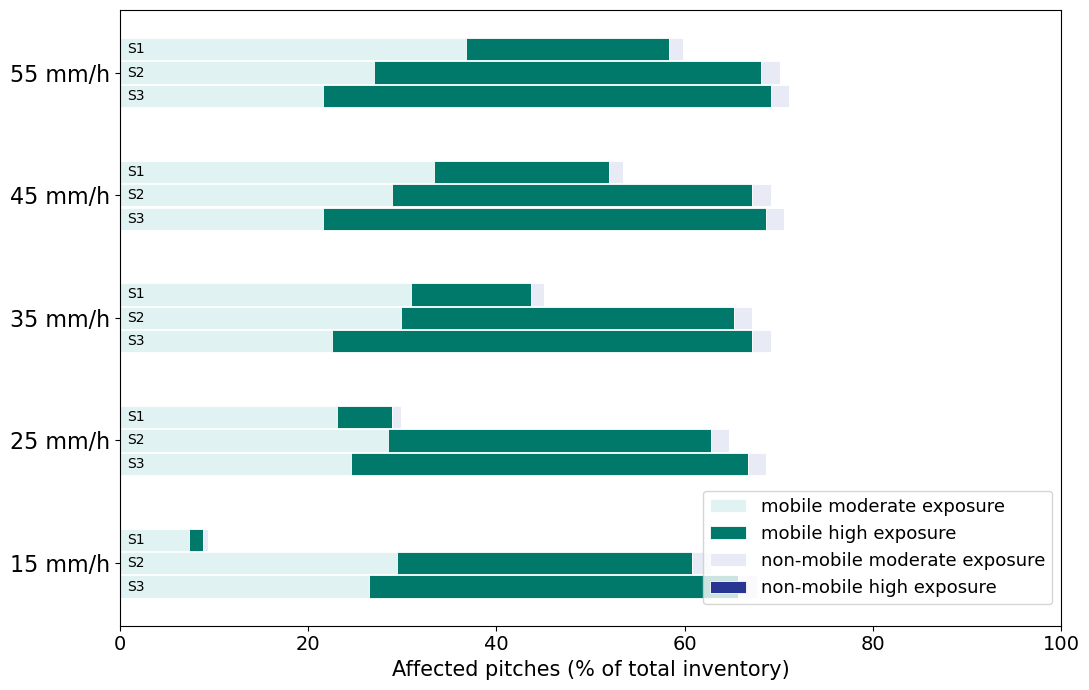

In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------

# S1, S2, S3 fractions
fractions_s1_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v4/fractions_long.csv"
fractions_s2_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v5/fractions_long.csv"
fractions_s3_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v6/fractions_long.csv"

# Totals used as denominator
# Use the same total inventory for all versions
totals_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_2m_v5/Morges_2m_v5_exposure.xlsx"

# Versions and scenarios to plot
versions_to_plot = ["v4", "v5", "v6"]
scenarios_to_plot = [15, 25, 35, 45, 55]

# Labels shown inside the bars
VERSION_LABELS = {
    "v4": "S1",
    "v5": "S2",
    "v6": "S3",
}

# --------------------------------------------------
# STACK ORDER + LABELS
# --------------------------------------------------

STACK_ORDER = [
    ("mobile", 1),
    ("mobile", 2),
    ("non_mobile", 1),
    ("non_mobile", 2),
]

LABELS = {
    ("mobile", 1):     "mobile moderate exposure",
    ("mobile", 2):     "mobile high exposure",
    ("non_mobile", 1): "non-mobile moderate exposure",
    ("non_mobile", 2): "non-mobile high exposure",
}

COLORS = {
    ("mobile", 1):     "#E0F2F1",
    ("mobile", 2):     "#00796B",
    ("non_mobile", 1): "#E8EAF6",
    ("non_mobile", 2): "#283593",
}

# --------------------------------------------------
# HELPERS
# --------------------------------------------------

def read_totals(path):
    p = Path(path)

    if p.suffix.lower() == ".csv":
        t = pd.read_csv(p).iloc[0]
    else:
        t = pd.read_excel(p, sheet_name="site_totals").iloc[0]

    def safe_int(x):
        try:
            if pd.isna(x):
                return 0
            return int(x)
        except Exception:
            return 0

    return (
        safe_int(t.get("mobile_total", 0)),
        safe_int(t.get("non_mobile_total", 0)),
    )


def fractions_to_pct_total(frac_long, totals):
    mobile_total, non_mobile_total = totals
    total_inventory = max(mobile_total + non_mobile_total, 1)

    def denom_for_group(g):
        g = str(g).lower().strip()
        if g == "mobile":
            return mobile_total
        if g == "non_mobile":
            return non_mobile_total
        return 0

    df = frac_long.copy()
    df["group"] = df["group"].astype(str).str.lower().str.strip()

    denom = df["group"].map(denom_for_group).astype(float)
    count = df["fraction"].astype(float) * denom

    df["pct_total"] = (count / total_inventory) * 100.0

    return df

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

s1 = pd.read_csv(fractions_s1_path)
s2 = pd.read_csv(fractions_s2_path)
s3 = pd.read_csv(fractions_s3_path)

frac_long = pd.concat([s1, s2, s3], ignore_index=True)

# Clean types
frac_long["version"] = frac_long["version"].astype(str).str.strip()
frac_long["group"] = frac_long["group"].astype(str).str.lower().str.strip()
frac_long["scenario"] = pd.to_numeric(frac_long["scenario"], errors="coerce")
frac_long["level"] = pd.to_numeric(frac_long["level"], errors="coerce")
frac_long["fraction"] = pd.to_numeric(frac_long["fraction"], errors="coerce")

frac_long = frac_long.dropna(subset=["scenario", "level", "fraction"])

frac_long["scenario"] = frac_long["scenario"].astype(int)
frac_long["level"] = frac_long["level"].astype(int)

print("Versions found in the files:")
print(frac_long["version"].unique())

print("Scenarios found:")
print(sorted(frac_long["scenario"].unique()))

# Filter wanted versions and scenarios
frac_long = frac_long[
    frac_long["version"].isin(versions_to_plot) &
    frac_long["scenario"].isin(scenarios_to_plot)
].copy()

print("Versions kept for plotting:")
print(frac_long["version"].unique())

# Read totals and convert fractions to percentage of total inventory
totals = read_totals(totals_path)
df = fractions_to_pct_total(frac_long, totals)

# --------------------------------------------------
# BUILD FULL GRID TO AVOID MISSING BARS
# --------------------------------------------------

grid_rows = []

for version in versions_to_plot:
    for scenario in scenarios_to_plot:
        for group, level in STACK_ORDER:
            grid_rows.append((version, scenario, group, level))

idx = pd.MultiIndex.from_tuples(
    grid_rows,
    names=["version", "scenario", "group", "level"]
)

df_full = (
    df.set_index(["version", "scenario", "group", "level"])
      .reindex(idx, fill_value=0.0)
      .reset_index()
)

# --------------------------------------------------
# BUILD Y-AXIS ROWS
# --------------------------------------------------

scenario_gap = 1.15
scenario_positions = [i * scenario_gap for i in range(len(scenarios_to_plot))]

row_labels = [f"{s} mm/h" for s in scenarios_to_plot]
ypos = np.array(scenario_positions)

scenario_to_y = {
    scenario: scenario_positions[i]
    for i, scenario in enumerate(scenarios_to_plot)
}

# --------------------------------------------------
# PLOT
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

# Transparent background
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# Bar height
bar_h = 0.22

# Offsets for S1, S2, S3
offset_values = np.linspace(bar_h, -bar_h, len(versions_to_plot))
offsets = dict(zip(versions_to_plot, offset_values))

for version in versions_to_plot:
    for scenario in scenarios_to_plot:
        y = scenario_to_y[scenario] + offsets[version]
        bottoms = 0.0

        for group, level in STACK_ORDER:
            val = df_full.loc[
                (df_full["version"] == version) &
                (df_full["scenario"] == scenario) &
                (df_full["group"] == group) &
                (df_full["level"] == level),
                "pct_total"
            ].values

            width = float(val[0]) if len(val) else 0.0

            ax.barh(
                y,
                width,
                left=bottoms,
                height=bar_h * 0.95,
                color=COLORS[(group, level)],
                edgecolor="white",
                linewidth=0.6,
                label=LABELS[(group, level)]
                if (version == versions_to_plot[0] and scenario == scenarios_to_plot[0])
                else None
            )

            bottoms += width

        # Add S1 / S2 / S3 label inside the bar area
        ax.text(
            0.8,
            y,
            VERSION_LABELS.get(version, version),
            va="center",
            ha="left",
            fontsize=10
        )

# Y-axis labels
ax.set_yticks(ypos)
ax.set_yticklabels(row_labels, fontsize=16)

# X-axis
ax.set_xlabel("Affected pitches (% of total inventory)", fontsize=15)
ax.set_xlim(0, 100)
ax.tick_params(axis="x", labelsize=14)

# No grid and no vertical dashed line
ax.grid(False)

# Legend
ax.legend(
    loc="lower right",
    bbox_to_anchor=(1.00, 0.02),
    frameon=True,
    fontsize=13
)

ax.set_title("", fontsize=13)

fig.tight_layout()
plt.show()

In [5]:
import numpy as np
import pandas as pd

def plot_flooded_area_two_versions(
    df_v2,
    df_v4,
    case_name=None,
    label_v2="S1",
    label_v4="S2",
    output_path=None,
    show=True,
    dpi=300,

    # --- Combiprecip args ---
    cp_timeseries_csv=None,
    cp_time_peak="2024-06-25 19:00:00",   # kept, but we use clock time below
    cp_label="Observed flooded area (19:00 UTC)",
    cp_x_mmph=25.0,                       # set None for auto, or set 25.0 to force at 25
    add_cp_range=False,                   # not used here
):
    import os
    from pathlib import Path
    import matplotlib.pyplot as plt

    # -------------------------
    # Load scenario CSVs if needed
    # -------------------------
    if isinstance(df_v2, (str, Path)):
        df_v2 = pd.read_csv(df_v2)
    if isinstance(df_v4, (str, Path)):
        df_v4 = pd.read_csv(df_v4)

    # -------------------------
    # Prepare scenario data
    # -------------------------
    a = df_v2[["Precipitation (mm/h)", "Flooded Area (%)"]].rename(columns={"Flooded Area (%)": "v2"}).copy()
    b = df_v4[["Precipitation (mm/h)", "Flooded Area (%)"]].rename(columns={"Flooded Area (%)": "v4"}).copy()

    a["Precipitation (mm/h)"] = pd.to_numeric(a["Precipitation (mm/h)"], errors="coerce")
    b["Precipitation (mm/h)"] = pd.to_numeric(b["Precipitation (mm/h)"], errors="coerce")
    a["v2"] = pd.to_numeric(a["v2"], errors="coerce")
    b["v4"] = pd.to_numeric(b["v4"], errors="coerce")

    a = a.dropna()
    b = b.dropna()

    m = pd.merge(a, b, on="Precipitation (mm/h)", how="inner").sort_values("Precipitation (mm/h)")
    if m.empty:
        raise ValueError("No matching precipitation values between v2 and v4 CSVs.")

    x  = m["Precipitation (mm/h)"].to_numpy(dtype=float)
    y2 = m["v2"].to_numpy(dtype=float)
    y4 = m["v4"].to_numpy(dtype=float)

    # -------------------------
    # Plot base figure
    # -------------------------
    c_v2 = "#4DB6AC"
    c_v4 = "#00796b"

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_alpha(0.0)
    ax.set_facecolor((1, 1, 1, 0))

    ax.plot(x, y2, marker="s", linewidth=2, markersize=6,
            color=c_v2, markerfacecolor=c_v2, markeredgecolor=c_v2, label=label_v2)
    ax.plot(x, y4, marker="s", linewidth=2, markersize=6,
            color=c_v4, markerfacecolor=c_v4, markeredgecolor=c_v4, label=label_v4)

    ax.fill_between(x, y2, y4, alpha=0.12, color=c_v4, label="Δ")

    # --------------------------------------------------
    # Add Combiprecip peak marker (ONLY the value at 19:00)
    # --------------------------------------------------
    if cp_timeseries_csv is not None:
        cp = pd.read_csv(cp_timeseries_csv)

        if "time" not in cp.columns or "Flooded Area (%)" not in cp.columns:
            raise ValueError("Combiprecip CSV must contain columns: 'time' and 'Flooded Area (%)'.")

        cp["time"] = pd.to_datetime(cp["time"], errors="coerce")
        cp["Flooded Area (%)"] = pd.to_numeric(cp["Flooded Area (%)"], errors="coerce")
        cp = cp.dropna(subset=["time", "Flooded Area (%)"]).sort_values("time")

        # Pick ONLY 19:00 by clock time (and by date, to avoid picking another day)
        cp_date = "2024-06-25"   # set None if you truly have only one day in the file
        cp_clock = "19:00"

        if cp_date is not None:
            mask = (
                (cp["time"].dt.strftime("%Y-%m-%d") == cp_date) &
                (cp["time"].dt.strftime("%H:%M") == cp_clock)
            )
        else:
            mask = (cp["time"].dt.strftime("%H:%M") == cp_clock)

        sel = cp.loc[mask, "Flooded Area (%)"]
        if sel.empty:
            raise ValueError(
                f"No Combiprecip row found for {cp_date or 'any date'} at {cp_clock}. "
                f"Check timestamps in CP CSV."
            )

        cp_peak = float(sel.iloc[0])

        # x-position: forced or auto
        if cp_x_mmph is None:
            ymid = 0.5 * (y2 + y4)
            ix = int(np.argmin(np.abs(ymid - cp_peak)))
            cp_x = float(x[ix])
        else:
            cp_x = float(cp_x_mmph)

        ax.scatter([cp_x], [cp_peak], marker="^", s=120, color="black",
                   zorder=10, label=cp_label)

        ax.text(cp_x + 0.6, cp_peak, f"{cp_peak:.1f}%",
                fontsize=12, va="center", ha="left", color="black")

    # -------------------------
    # Styling
    # -------------------------
    ax.set_xlabel("Precipitation (mm/h)")
    ax.set_ylabel("Flooded Area (%)")
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=17, length=4, width=1)
    ax.legend(frameon=False, loc="best",fontsize=16)

    plt.tight_layout()

    if output_path:
        outdir = os.path.dirname(output_path) or "."
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, transparent=True, bbox_inches="tight")
        if not show:
            plt.close(fig)

    if show:
        plt.show()

    return m

/tmp/ipykernel_1443673/2668265795.py:81: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cp["time"] = pd.to_datetime(cp["time"], errors="coerce")


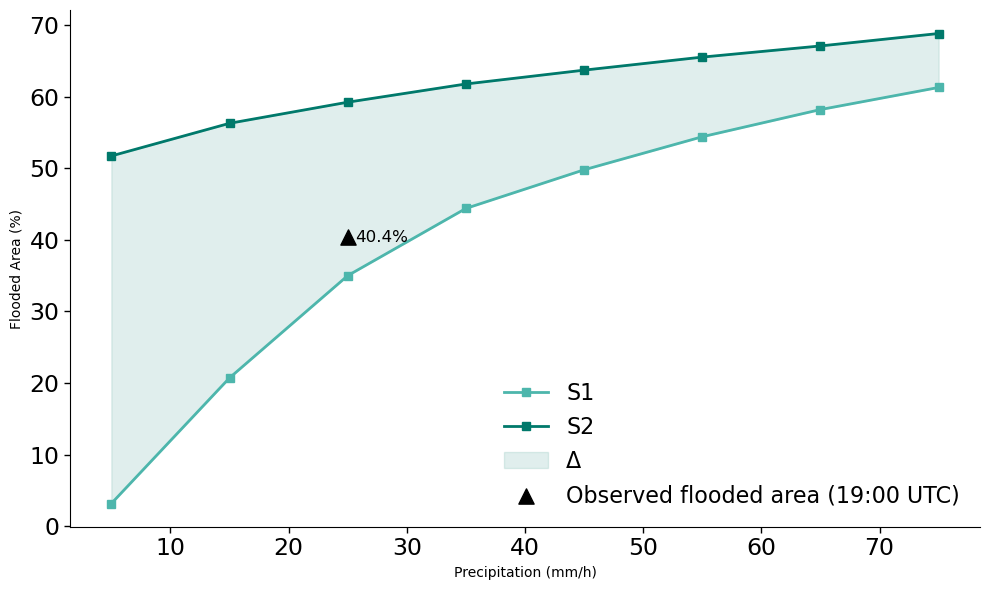

,Precipitation (mm/h),v2,v4
0,5,3.170667,51.718025
1,15,20.720586,56.279336
2,25,35.002493,59.227499
3,35,44.389335,61.772377
4,45,49.785031,63.705371
5,55,54.401967,65.527114
6,65,58.198423,67.084634
7,75,61.285652,68.822938


In [6]:
plot_flooded_area_two_versions(
    df_v2="/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_v2/MORGES_flooded_area_fv1.csv",
    df_v4="/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_v4/MORGES_flooded_area_fv1.csv",
    cp_timeseries_csv="/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_CP/MORGES_CP_flooded_area_timeseries.csv",
    cp_x_mmph=25.0,
    output_path="/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_S1_S2_CP.jpg",
    show=True
)

In [4]:
import numpy as np
import pandas as pd

def plot_flooded_area_three_versions(
    df_v2,
    df_v4,
    df_v5,
    case_name=None,
    label_v2="S1",
    label_v4="S2",
    label_v5="S3",
    output_path=None,
    show=True,
    dpi=300,

    # --- Combiprecip args ---
    cp_timeseries_csv=None,
    cp_time_peak="2024-06-25 19:00:00",
    cp_label="Observed flooded area (19:00 UTC)",
    cp_x_mmph=25.0,
    add_cp_range=False,
):
    import os
    from pathlib import Path
    import matplotlib.pyplot as plt

    # -------------------------
    # Load scenario CSVs if needed
    # -------------------------
    if isinstance(df_v2, (str, Path)):
        df_v2 = pd.read_csv(df_v2)
    if isinstance(df_v4, (str, Path)):
        df_v4 = pd.read_csv(df_v4)
    if isinstance(df_v5, (str, Path)):
        df_v5 = pd.read_csv(df_v5)

    # -------------------------
    # Prepare scenario data
    # -------------------------
    a = df_v2[["Precipitation (mm/h)", "Flooded Area (%)"]].rename(
        columns={"Flooded Area (%)": "v2"}
    ).copy()

    b = df_v4[["Precipitation (mm/h)", "Flooded Area (%)"]].rename(
        columns={"Flooded Area (%)": "v4"}
    ).copy()

    c = df_v5[["Precipitation (mm/h)", "Flooded Area (%)"]].rename(
        columns={"Flooded Area (%)": "v5"}
    ).copy()

    for df_, col in [(a, "v2"), (b, "v4"), (c, "v5")]:
        df_["Precipitation (mm/h)"] = pd.to_numeric(df_["Precipitation (mm/h)"], errors="coerce")
        df_[col] = pd.to_numeric(df_[col], errors="coerce")

    a = a.dropna()
    b = b.dropna()
    c = c.dropna()

    m = (
        a.merge(b, on="Precipitation (mm/h)", how="inner")
         .merge(c, on="Precipitation (mm/h)", how="inner")
         .sort_values("Precipitation (mm/h)")
    )

    if m.empty:
        raise ValueError("No matching precipitation values between the three CSVs.")

    x  = m["Precipitation (mm/h)"].to_numpy(dtype=float)
    y2 = m["v2"].to_numpy(dtype=float)
    y4 = m["v4"].to_numpy(dtype=float)
    y5 = m["v5"].to_numpy(dtype=float)

    # -------------------------
    # Plot base figure
    # -------------------------
    c_v2 = "#4DB6AC"   # S1
    c_v4 = "#00796B"   # S2
    c_v5 = "#5E35B1"   # S3

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_alpha(0.0)
    ax.set_facecolor((1, 1, 1, 0))

    ax.plot(
        x, y2, marker="s", linewidth=2, markersize=6,
        color=c_v2, markerfacecolor=c_v2, markeredgecolor=c_v2, label=label_v2
    )

    ax.plot(
        x, y4, marker="s", linewidth=2, markersize=6,
        color=c_v4, markerfacecolor=c_v4, markeredgecolor=c_v4, label=label_v4
    )

    ax.plot(
        x, y5, marker="s", linewidth=2, markersize=6,
        color=c_v5, markerfacecolor=c_v5, markeredgecolor=c_v5, label=label_v5
    )

    # Optional shaded differences
    ax.fill_between(x, y2, y4, alpha=0.10, color=c_v4, label="Δ S1–S2")
    ax.fill_between(x, y4, y5, alpha=0.10, color=c_v5, label="Δ S2–S3")

    # --------------------------------------------------
    # Add Combiprecip peak marker
    # --------------------------------------------------
    if cp_timeseries_csv is not None:
        cp = pd.read_csv(cp_timeseries_csv)

        if "time" not in cp.columns or "Flooded Area (%)" not in cp.columns:
            raise ValueError("Combiprecip CSV must contain columns: 'time' and 'Flooded Area (%)'.")

        cp["time"] = pd.to_datetime(cp["time"], errors="coerce")
        cp["Flooded Area (%)"] = pd.to_numeric(cp["Flooded Area (%)"], errors="coerce")
        cp = cp.dropna(subset=["time", "Flooded Area (%)"]).sort_values("time")

        cp_date = "2024-06-25"
        cp_clock = "19:00"

        mask = (
            (cp["time"].dt.strftime("%Y-%m-%d") == cp_date) &
            (cp["time"].dt.strftime("%H:%M") == cp_clock)
        )

        sel = cp.loc[mask, "Flooded Area (%)"]

        if sel.empty:
            raise ValueError("No Combiprecip row found for 19:00.")

        cp_peak = float(sel.iloc[0])

        if cp_x_mmph is None:
            ymid = (y2 + y4 + y5) / 3.0
            ix = int(np.argmin(np.abs(ymid - cp_peak)))
            cp_x = float(x[ix])
        else:
            cp_x = float(cp_x_mmph)

        ax.scatter(
            [cp_x], [cp_peak],
            marker="^", s=120, color="black",
            zorder=10, label=cp_label
        )

        ax.text(
            cp_x + 0.6, cp_peak, f"{cp_peak:.1f}%",
            fontsize=12, va="center", ha="left", color="black"
        )

    # -------------------------
    # Styling
    # -------------------------
    ax.set_xlabel("Precipitation (mm/h)", fontsize=17)
    ax.set_ylabel("Flooded Area (%)", fontsize=17)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=17, length=4, width=1)
    ax.legend(frameon=False, loc="best", fontsize=16)

    plt.tight_layout()

    if output_path:
        outdir = os.path.dirname(output_path) or "."
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, transparent=True, bbox_inches="tight")
        if not show:
            plt.close(fig)

    if show:
        plt.show()

    return m

/tmp/ipykernel_2914494/3812871025.py:113: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cp["time"] = pd.to_datetime(cp["time"], errors="coerce")


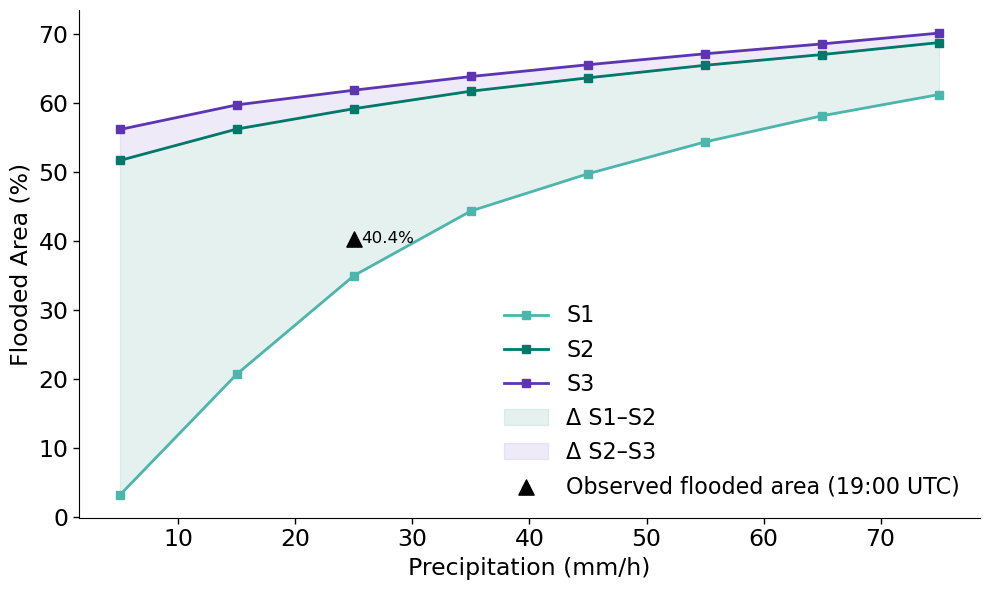

,Precipitation (mm/h),v2,v4,v5
0,5,3.170667,51.718025,56.209803
1,15,20.720586,56.279336,59.783757
2,25,35.002493,59.227499,61.911441
3,35,44.389335,61.772377,63.900061
4,45,49.785031,63.705371,65.610552
5,55,54.401967,65.527114,67.195886
6,65,58.198423,67.084634,68.628248
7,75,61.285652,68.822938,70.199675


In [4]:
plot_flooded_area_three_versions(
    df_v2="/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_v2/MORGES_flooded_area_fv1.csv",
    df_v4="/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_v4/MORGES_flooded_area_fv1.csv",
    df_v5="/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_v5/MORGES_flooded_area_fv1.csv",

    cp_timeseries_csv="/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_CP/MORGES_CP_flooded_area_timeseries.csv",

    cp_x_mmph=25.0,

    output_path="/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_S1_S2_S3_CP.jpg",

    show=True
)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_flooded_area_three_versions(
    df_v2,
    df_v5,
    df_v6,
    case_name=None,
    label_v2="S1",
    label_v5="S2",
    label_v6="S3",
    output_path=None,
    show=True,
    dpi=300,
):
    import os

    # -------------------------
    # Load scenario CSVs if paths are given
    # -------------------------
    if isinstance(df_v2, (str, Path)):
        df_v2 = pd.read_csv(df_v2)

    if isinstance(df_v5, (str, Path)):
        df_v5 = pd.read_csv(df_v5)

    if isinstance(df_v6, (str, Path)):
        df_v6 = pd.read_csv(df_v6)

    # -------------------------
    # Prepare scenario data
    # -------------------------
    a = df_v2[["Precipitation (mm/h)", "Flooded Area (%)"]].rename(
        columns={"Flooded Area (%)": "v2"}
    ).copy()

    b = df_v5[["Precipitation (mm/h)", "Flooded Area (%)"]].rename(
        columns={"Flooded Area (%)": "v5"}
    ).copy()

    c = df_v6[["Precipitation (mm/h)", "Flooded Area (%)"]].rename(
        columns={"Flooded Area (%)": "v6"}
    ).copy()

    for df_, col in [(a, "v2"), (b, "v5"), (c, "v6")]:
        df_["Precipitation (mm/h)"] = pd.to_numeric(
            df_["Precipitation (mm/h)"], errors="coerce"
        )
        df_[col] = pd.to_numeric(df_[col], errors="coerce")

    a = a.dropna()
    b = b.dropna()
    c = c.dropna()

    m = (
        a.merge(b, on="Precipitation (mm/h)", how="inner")
         .merge(c, on="Precipitation (mm/h)", how="inner")
         .sort_values("Precipitation (mm/h)")
    )

    if m.empty:
        raise ValueError("No matching precipitation values between v2, v5, and v6.")

    x = m["Precipitation (mm/h)"].to_numpy(dtype=float)
    y2 = m["v2"].to_numpy(dtype=float)
    y5 = m["v5"].to_numpy(dtype=float)
    y6 = m["v6"].to_numpy(dtype=float)

    # -------------------------
    # Plot
    # -------------------------
    c_v2 = "#4DB6AC"   # S1
    c_v5 = "#00796B"   # S2
    c_v6 = "#5E35B1"   # S3

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_alpha(0.0)
    ax.set_facecolor((1, 1, 1, 0))

    ax.plot(
        x, y2,
        marker="s",
        linewidth=2,
        markersize=6,
        color=c_v2,
        markerfacecolor=c_v2,
        markeredgecolor=c_v2,
        label=label_v2
    )

    ax.plot(
        x, y5,
        marker="s",
        linewidth=2,
        markersize=6,
        color=c_v5,
        markerfacecolor=c_v5,
        markeredgecolor=c_v5,
        label=label_v5
    )

    ax.plot(
        x, y6,
        marker="s",
        linewidth=2,
        markersize=6,
        color=c_v6,
        markerfacecolor=c_v6,
        markeredgecolor=c_v6,
        label=label_v6
    )

    # Optional shaded differences between storylines
    ax.fill_between(x, y2, y5, alpha=0.10, color=c_v5, label="Difference S1--S2")
    ax.fill_between(x, y5, y6, alpha=0.10, color=c_v6, label="Difference S2--S3")

    # -------------------------
    # Styling
    # -------------------------
    ax.set_xlabel("Precipitation (mm/h)", fontsize=17)
    ax.set_ylabel("Flooded area (%)", fontsize=17)

    if case_name is not None:
        ax.set_title(case_name, fontsize=17)

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=17, length=4, width=1)

    ax.legend(frameon=False, loc="best", fontsize=16)

    plt.tight_layout()

    if output_path:
        outdir = os.path.dirname(output_path) or "."
        os.makedirs(outdir, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, transparent=True, bbox_inches="tight")

        if not show:
            plt.close(fig)

    if show:
        plt.show()

    return m

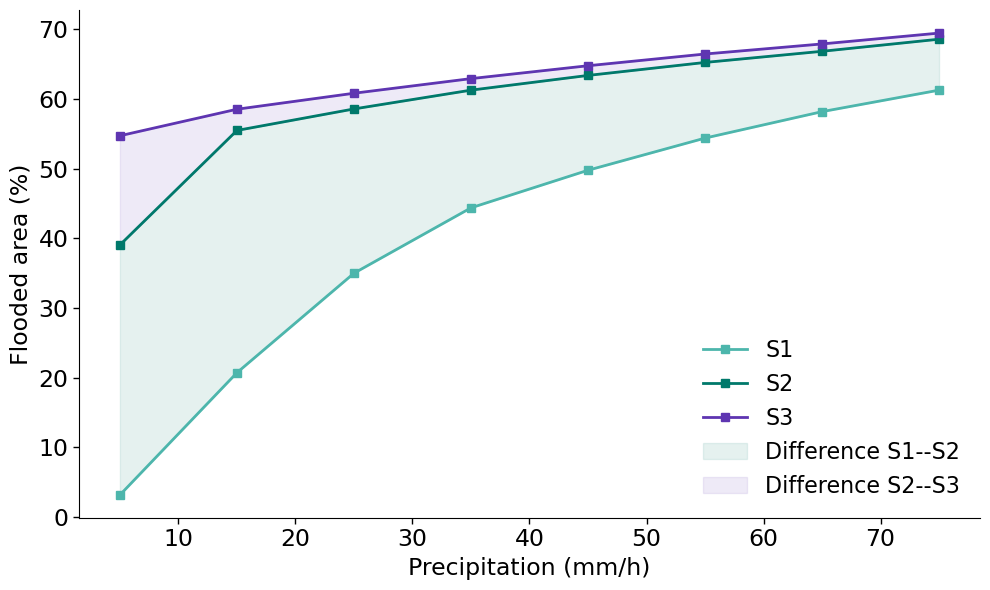

,Precipitation (mm/h),v2,v5,v6
0,5,3.170667,39.063171,54.735721
1,15,20.720586,55.500575,58.546084
2,25,35.002493,58.587803,60.840646
3,35,44.389335,61.285652,62.940517
4,45,49.785031,63.399429,64.790073
5,55,54.401967,65.262891,66.472751
6,65,58.198423,66.862131,67.919020
7,75,61.285652,68.600435,69.476541


In [2]:
flooded_area_v2 = "/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_v2/MORGES_flooded_area_fv1.csv"
flooded_area_v5 = "/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_v5/MORGES_flooded_area_fv1.csv"
flooded_area_v6 = "/storage/homefs/ge24z347/Flood_area_Campgrounds/Morges_2m_v6/MORGES_flooded_area_fv1.csv"

plot_flooded_area_three_versions(
    flooded_area_v2,
    flooded_area_v5,
    flooded_area_v6,
    case_name="",
    label_v2="S1",
    label_v5="S2",
    label_v6="S3",
    output_path="/storage/homefs/ge24z347/exposure_results_campgrounds/Morges_flooded_area_S1_S2_S3.png",
    show=True
)